# **Fraud Detection and Cost Optimization using Machine Learning Algorithms**

### Purpose:
The purpose of the analysis is to find the best model to detect fraud and optimize the cost to minimize the loss. 

### Steps
1. Clean the data
2. Perform EDA
3. Train the model
4. Cost optimization for loss minimization
5. Sprints

### Analytics Questions
 Descriptive
 
1. What is the distribution of fraudulent to legitimate transactions?
2. What differences exist between fraud and non‑fraud transaction amounts, and where do fraud spikes occur?
3. What hours of the day experience the highest frequency of fraud?
   
Diagnostic

4. Why do certain geographic regions have higher fraud rates and abnormal fraud patterns?
5. Why do certain devices show abnormal fraud behavior, and why is device uniqueness associated with higher fraud risk?

Predictive

6. How risky is each transaction before we approve it?
7. How many of the frauds coming in are we actually catching?

Prescriptive

8. When should we schedule extra review staff to cover riskiest hours?
9. Given our team's size, what's the safe range for how aggressively we block transactions? 
10. How much does the new system save us compared to the traditional approach, across different settings?

### **Import package**

In [1]:
!pip install lightgbm catboost tensorflow

In [2]:
!pip install mysql-connector-python

### Import Librarires 

In [3]:
import numpy as np
import pandas as pd
import datetime
import gc

from sqlalchemy import create_engine, text

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
 

import lightgbm as lgb
import catboost as cb

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
# Connect the database and test connection
connection_url = (
    f"mysql+mysqlconnector://root:NewPassword123!"
    f"@localhost:3306/FraudDetectionDB2"
 )

# Connection testing
engine = create_engine(connection_url, pool_pre_ping=True)

with engine.connect() as connection:
    result = connection.execute(text("SELECT 1"))
    print(result.fetchall())

[(1,)]


In [5]:
# Loading the tables in batch from the database
def load_table(name):
    query = f"SELECT * FROM {name}"
    chunks = pd.read_sql(query, engine, chunksize=50000)
    return pd.concat(chunks, ignore_index=True)

fact = load_table("fact_transaction")
card = load_table("card_features")
loc = load_table("location_features")
email = load_table("email_features")
c = load_table("C_features")
d = load_table("D_features")
m = load_table("M_features")
v1 = load_table("V1_features")
v2 = load_table("V2_features")
v3 = load_table("V3_features")
v4 = load_table("V4_features")
v5 = load_table("V5_features")
v6 = load_table("V6_features")
v7 = load_table("V7_features")
identity = load_table("identity_features")

print("All tables loaded successfully.")

In [6]:
# Merge the tables to prepare for analysis
df = (
    fact
    .merge(card, on="TransactionID", how="left")
    .merge(loc, on="TransactionID", how="left")
    .merge(email, on="TransactionID", how="left")
    .merge(c, on="TransactionID", how="left")
    .merge(d, on="TransactionID", how="left")
    .merge(m, on="TransactionID", how="left")
    .merge(v1, on="TransactionID", how="left")
    .merge(v2, on="TransactionID", how="left")
    .merge(v3, on="TransactionID", how="left")
    .merge(v4, on="TransactionID", how="left")
    .merge(v5, on="TransactionID", how="left")
    .merge(v6, on="TransactionID", how="left")
    .merge(v7, on="TransactionID", how="left")
    .merge(identity, on="TransactionID", how="left")
)

print("Merged dataset shape:", df.shape)

Merged dataset shape: (590540, 434)


In [7]:
df.head(5)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,0,150,discover,142,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404,150,mastercard,102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490,150,visa,166,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567,150,mastercard,117,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514,150,mastercard,102,...,samsung browser 6.2,32,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## **1.DATA CLEANING & FEATURE ENGINEERING**

Optimize RAM

In [8]:
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    return df

In [9]:
df = reduce_mem_usage(df)

**1.2 Sort by time**

Convert TransactionDT column from timedelta to real date time

In [10]:
#convert to datetime
START_DATE = '2017-11-30'
startdate = datetime.datetime.strptime(START_DATE, '%Y-%m-%d')
df['TransactionDT'] = df['TransactionDT'].apply(lambda x: startdate + datetime.timedelta(seconds = x))

#reset index to make the time sequential
df = df.sort_values('TransactionDT'). reset_index(drop = True)



In [11]:
df['TransactionDT'].head(5)


0   2017-12-01 00:00:00
1   2017-12-01 00:00:01
2   2017-12-01 00:01:09
3   2017-12-01 00:01:39
4   2017-12-01 00:01:46
Name: TransactionDT, dtype: datetime64[ns]

**1.3 Parse DeviceInfo/id_30/id_31 & Group Device name** 

In [12]:
#flag if transaction with identity or not 
df['had_id'] = df['id_01'].notnull().astype(int)


In [13]:
#Check dtype for id_*
id_cols = [ col for col in df.columns if col.startswith('id_')]

for col in id_cols:
    print(f'{col}:', df[col].dtype)

id_01: object
id_02: object
id_03: object
id_04: object
id_05: object
id_06: object
id_07: object
id_08: object
id_09: object
id_10: object
id_11: object
id_12: object
id_13: object
id_14: object
id_15: object
id_16: object
id_17: object
id_18: object
id_19: object
id_20: object
id_21: object
id_22: object
id_23: object
id_24: object
id_25: object
id_26: object
id_27: object
id_28: object
id_29: object
id_30: object
id_31: object
id_32: object
id_33: object
id_34: object
id_35: object
id_36: object
id_37: object
id_38: object


In [14]:
object_cols = ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29',
               'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

for col in object_cols:
    print(f'{col}: nunique={df[col].nunique()}, sample={df[col].dropna().unique()[:3]}')

id_12: nunique=2, sample=['NotFound' 'Found']
id_15: nunique=4, sample=['New' 'Found' '']
id_16: nunique=3, sample=['NotFound' 'Found' '']
id_23: nunique=4, sample=['' 'IP_PROXY:TRANSPARENT' 'IP_PROXY:ANONYMOUS']
id_27: nunique=3, sample=['' 'Found' 'NotFound']
id_28: nunique=3, sample=['New' 'Found' '']
id_29: nunique=3, sample=['NotFound' 'Found' '']
id_30: nunique=76, sample=['Android 7.0' 'iOS 11.1.2' '']
id_31: nunique=131, sample=['samsung browser 6.2' 'mobile safari 11.0' 'chrome 62.0']
id_33: nunique=261, sample=['2220x1080' '1334x750' '']
id_34: nunique=5, sample=['match_status:2' 'match_status:1' '']
id_35: nunique=3, sample=['T' 'F' '']
id_36: nunique=3, sample=['F' '' 'T']
id_37: nunique=3, sample=['T' 'F' '']
id_38: nunique=3, sample=['T' '' 'F']


 

These 3 columns are compound strings that have high cardinality:
- `id_30` (OS): 75 unique values, e.g. "Android 7.0" -> split by space, keep name only
- `id_31` (browser): 130 unique values, e.g. "chrome 62.0" -> split by space, keep name only
- `id_33` (screen res): 260 unique values, e.g. "2220x1080" -> But  is skipped here on assumption that screen resolution has low relevance to fraud detection.

Other object-typed id columns (id_12, id_15, id_23, id_27, id_28, id_29, id_34, 
id_35-38) have low cardinality (2-4 values) then no splitting needed. Remaining id 
columns are numeric (float32) and untouched by this function.


In [15]:
def id_split(dataframe):
    dataframe['device_name']    = dataframe['DeviceInfo'].str.split('/', expand=True)[0]
    dataframe['device_version'] = dataframe['DeviceInfo'].str.split('/', expand=True)[1]
    dataframe['OS_id_30']       = dataframe['id_30'].str.split(' ', expand=True)[0]
    dataframe['browser_id_31']  = dataframe['id_31'].str.split(' ', expand=True)[0]
    
    #group device_name
    
    dataframe.loc[dataframe['device_name'].str.contains('SM', na=False), 'device_name'] = 'Samsung'
    dataframe.loc[dataframe['device_name'].str.contains('SAMSUNG', na=False), 'device_name'] = 'Samsung'
    dataframe.loc[dataframe['device_name'].str.contains('GT-', na=False), 'device_name'] = 'Samsung'
    dataframe.loc[dataframe['device_name'].str.contains('Moto G', na=False), 'device_name'] = 'Motorola'
    dataframe.loc[dataframe['device_name'].str.contains('Moto', na=False), 'device_name'] = 'Motorola'
    dataframe.loc[dataframe['device_name'].str.contains('moto', na=False), 'device_name'] = 'Motorola'
    dataframe.loc[dataframe['device_name'].str.contains('LG-', na=False), 'device_name'] = 'LG'
    dataframe.loc[dataframe['device_name'].str.contains('rv:', na=False), 'device_name'] = 'RV'
    dataframe.loc[dataframe['device_name'].str.contains('HUAWEI', na=False), 'device_name'] = 'Huawei'
    dataframe.loc[dataframe['device_name'].str.contains('ALE-', na=False), 'device_name'] = 'Huawei'
    dataframe.loc[dataframe['device_name'].str.contains('-L', na=False), 'device_name'] = 'Huawei'
    dataframe.loc[dataframe['device_name'].str.contains('Blade', na=False), 'device_name'] = 'ZTE'
    dataframe.loc[dataframe['device_name'].str.contains('BLADE', na=False), 'device_name'] = 'ZTE'
    dataframe.loc[dataframe['device_name'].str.contains('Linux', na=False), 'device_name'] = 'Linux'
    dataframe.loc[dataframe['device_name'].str.contains('XT', na=False), 'device_name'] = 'Sony'
    dataframe.loc[dataframe['device_name'].str.contains('HTC', na=False), 'device_name'] = 'HTC'
    dataframe.loc[dataframe['device_name'].str.contains('ASUS', na=False), 'device_name'] = 'Asus'
    dataframe.loc[dataframe['device_name'].str.contains('iOS|MacOS|Mac OS|iPhone|iPad', case=False, na=False),'device_name'] = 'Apple'

    dataframe.loc[dataframe.device_name.isin(dataframe.device_name.value_counts()[dataframe.device_name.value_counts() < 100].index), 'device_name'] = "Others"
    
    gc.collect()
    return dataframe

In [16]:
df = id_split(df)


In [17]:
df['OS_id_30'].iloc[ -50:]

590490        NaN
590491        NaN
590492        NaN
590493        NaN
590494        NaN
590495    Windows
590496        NaN
590497        NaN
590498        NaN
590499           
590500        NaN
590501           
590502        NaN
590503        NaN
590504        NaN
590505        NaN
590506    Windows
590507        NaN
590508        NaN
590509           
590510        NaN
590511        NaN
590512        NaN
590513        NaN
590514        NaN
590515        NaN
590516        NaN
590517        NaN
590518        NaN
590519        NaN
590520        NaN
590521           
590522        NaN
590523        NaN
590524        NaN
590525        NaN
590526    Android
590527        NaN
590528        NaN
590529           
590530        NaN
590531        Mac
590532        NaN
590533        NaN
590534           
590535        NaN
590536        NaN
590537        NaN
590538        NaN
590539        NaN
Name: OS_id_30, dtype: object

In [18]:
df['device_name'].iloc[ -50:]

590490         NaN
590491         NaN
590492         NaN
590493         NaN
590494         NaN
590495     Windows
590496         NaN
590497         NaN
590498         NaN
590499     Windows
590500         NaN
590501     Windows
590502         NaN
590503         NaN
590504         NaN
590505         NaN
590506     Trident
590507         NaN
590508         NaN
590509     Samsung
590510         NaN
590511         NaN
590512         NaN
590513         NaN
590514         NaN
590515         NaN
590516         NaN
590517         NaN
590518         NaN
590519         NaN
590520         NaN
590521      Others
590522         NaN
590523         NaN
590524         NaN
590525         NaN
590526      Others
590527         NaN
590528         NaN
590529    Motorola
590530         NaN
590531       Apple
590532         NaN
590533         NaN
590534      Huawei
590535         NaN
590536         NaN
590537         NaN
590538         NaN
590539         NaN
Name: device_name, dtype: object

## 1.3 Feature Engineering

**1.5.1 Create DT_D and uid1 (synthetic User ID)**

Purpose: the raw dataset has no "user_id" column at all, so we have to construct a customer identifier ourselves by combining card-related fields

In [19]:

# DT_D = "what day number is it today", counted from the dataset's start date
# Used to compare timing across different transactions
df['DT_D'] = ((df['TransactionDT'].dt.year - 2017) * 365 + df['TransactionDT'].dt.dayofyear).astype(np.int16)

# open_card = DT_D - D1
# D1 = "how many days has this card been in use" (as of the current transaction)
# DT_D - D1 will always produce the SAME number for every transaction on the same card,
# because it's essentially "the day this card first appeared in the data" (like a birth year)
# -> using this fixed number helps correctly identify the same card, avoiding mixing up different users
df['open_card'] = df.DT_D - df['D1']

# uid1 = a synthetic "customer ID"
# Combines: 6 card columns (card1-card6) + 2 address columns (addr1, addr2) + open_card
# Logic: if 2 transactions share the EXACT same values across all 9 fields -> they're very likely the same real customer
df['uid1'] = df['card1'].astype(str) +' '+ df['card2'].astype(str)+' '+ df['card3'].astype(str)+' '+df['card4'].astype(str)+' '+ df['card5'].astype(str)+' '+ df['card6'].astype(str) +' '+ df['addr1'].astype(str)+' '+df['addr2'].astype(str)+' '+df['open_card'].astype(str)

# Check: number of estimated "users" identified
print(df['uid1'].nunique())


222280


Original dataset size

- `df`: 590,540 rows 

 Result

- `df['uid1'].nunique()` = 222,518


590,540 rows / 222,518 uid1 ≈ 2.65 transactions/user (average)

→ This means on average, each user made about 2.65 transactions.

**1.5.2 Decive_hash + user/device count**


Combine 6 device-related columns (id_30, id_31, id_32, id_33, DeviceType, 
DeviceInfo) into a single hashed device ID (`device_hash`) using vectorized string concatenation
Then compute 2 counting features:
- `uid_device_nunique`: how many different devices one user (uid1) has used 
  -> high value = possible account takeover (fraudster logging in from a new device)
- `device_uid_nunique`: how many different users share the same device 
  -> high value = possible fraud ring (one device used to test/spend multiple stolen cards)

In [20]:
# 1. Build device_hash via vectorized string concatenation
df['device_hash'] = (
    df['id_30'].astype(str) + '_' +
    df['id_31'].astype(str) + '_' +
    df['id_32'].astype(str) + '_' +
    df['id_33'].astype(str) + '_' +
    df['DeviceType'].astype(str) + '_' +
    df['DeviceInfo'].astype(str)
)

# 2. Feature 1: number of distinct devices used by each user (uid1)
tmp = df.groupby('uid1')['device_hash'].nunique()
df['uid_device_nunique'] = df['uid1'].map(tmp)

# 3. Feature 2: number of distinct users sharing the same device
tmp = df.groupby('device_hash')['uid1'].nunique()
df['device_uid_nunique'] = df['device_hash'].map(tmp)

# Free memory
del tmp
gc.collect()

0

**1.5.3 Time feature + email domain compare + drop D9**


- `dow`, `hour`: extract day-of-week (0=Monday...6=Sunday) and hour-of-day 
  from `TransactionDT`. 
- `email_domain_comp`: flags whether purchaser email domain matches 
  recipient email domain (1 = match, 0 = mismatch/missing) -> mismatch 
  can indicate suspicious behavior (e.g. buying on someone else's behalf, 
  fake email).
- Drop `D9`: removed, likely because it overlaps in meaning with `hour` 
  (per Kaggle's data description, D9 also relates to time-of-day of the 
  transaction).

In [21]:
df['dow'] = df['TransactionDT'].dt.dayofweek
df['hour'] = df['TransactionDT'].dt.hour

# 3-way flag: 1 = match, 0 = mismatch, -999 = at least one domain missing
_p = df['P_emaildomain']
_r = df['R_emaildomain']
df['email_domain_comp'] = np.where(
    _p.isna() | _r.isna(), -999,
    (_p.values == _r.values).astype(int)
)
del _p, _r

df.drop(['D9'], axis=1, inplace=True)


In [22]:
print(df[['dow', 'hour', 'email_domain_comp']].head())
print(df.groupby('hour')['isFraud'].mean())   

   dow  hour  email_domain_comp
0    4     0                  1
1    4     0                  0
2    4     0                  0
3    4     0                  0
4    4     0                  0
hour
0     0.031380
1     0.031314
2     0.037483
3     0.038314
4     0.051890
5     0.070302
6     0.077743
7     0.106102
8     0.093014
9     0.089956
10    0.053212
11    0.038816
12    0.030439
13    0.022889
14    0.024216
15    0.025399
16    0.029511
17    0.031530
18    0.035231
19    0.034738
20    0.034273
21    0.034005
22    0.032694
23    0.036997
Name: isFraud, dtype: float64


Verified against real data: fraud rate spikes 
  during hours 4-9 (up to ~10.6% at hour 7), vs. ~2-4% during other hours 
  

### **1.6 Encode Categorical**

Convert each categorical column (text values like "visa", "chrome") into 
integers, since tree-based models (LightGBM/XGBoost/CatBoost) can't process 
text directly.

In [23]:
cat_columns = ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
               'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain',
               'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
               'DeviceType', 'DeviceInfo', 'device_name', 'device_version',
               'OS_id_30', 'browser_id_31', 'uid1',
               'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18',
               'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25',
               'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32',
               'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']



In [24]:

for f in cat_columns:
    lbl = LabelEncoder()
    lbl.fit(list(df[f].astype(str)))
    df[f] = lbl.transform(df[f].astype(str))

In [25]:
missing_cols = [c for c in cat_columns if c not in df.columns]
print(missing_cols)  
#double check to see any missing columns haven't been encoded

[]


# **1.7 Handling Duplicates**

In [30]:
# Baseline check 
baseline_duplicates = df.duplicated().sum()
print(f"[Baseline] Duplicates in original df: {baseline_duplicates}")  

[Baseline] Duplicates in original df: 0


In [31]:
# Inject synthetic duplicates  
df_test = df.copy()

N_INJECT = 15    
dup_sample = df_test.sample(N_INJECT, random_state=42)
df_test = pd.concat([df_test, dup_sample], ignore_index=True)

before_rows = len(df_test)
before_dupes = df_test.duplicated().sum()
print(f"\n[Before cleaning] Total rows: {before_rows} | Duplicates: {before_dupes}")


[Before cleaning] Total rows: 590555 | Duplicates: 15


In [32]:
#  Solution  remove duplicates
df_cleaned = df_test.drop_duplicates()
after_rows = len(df_cleaned)
after_dupes = df_cleaned.duplicated().sum()
print(f"[After cleaning]  Total rows: {after_rows} | Duplicates: {after_dupes}")

[After cleaning]  Total rows: 590540 | Duplicates: 0


In [33]:
# Verify pipeline works correctly
assert after_rows == len(df), " Row count after cleaning does not match original df!"
assert after_dupes == 0, " Duplicates still remain after cleaning!"
print("\n Duplicate Guard passed: injected duplicates fully removed, original data untouched.")

#Summary table  
duplicate_guard_summary = pd.DataFrame([
    {'Stage': 'Original data (baseline)', 'Total Rows': len(df), 'Duplicates': baseline_duplicates},
    {'Stage': 'After injection', 'Total Rows': before_rows, 'Duplicates': before_dupes},
    {'Stage': 'After cleaning', 'Total Rows': after_rows, 'Duplicates': after_dupes},
])
duplicate_guard_summary


 Duplicate Guard passed: injected duplicates fully removed, original data untouched.


,Stage,Total Rows,Duplicates
0,Original data (baseline),590540,0
1,After injection,590555,15
2,After cleaning,590540,0


# **1.8 Handling Errors**

In [34]:
#Baseline check on the real data

baseline_errors = {
    'Negative TransactionAmt': (df['TransactionAmt'] < 0).sum(),
    'Null TransactionAmt': df['TransactionAmt'].isnull().sum(),
    'isFraud not in {0,1}': (~df['isFraud'].isin([0, 1])).sum(),
}
print("[Baseline] Errors in original df:", baseline_errors)

#Inject synthetic errors 
df_test = df.copy()

idx_negative = df_test.sample(5, random_state=1).index
df_test.loc[idx_negative, 'TransactionAmt'] = -999

idx_null = df_test.sample(5, random_state=2).index
df_test.loc[idx_null, 'TransactionAmt'] = np.nan

idx_invalid_label = df_test.sample(3, random_state=3).index
df_test.loc[idx_invalid_label, 'isFraud'] = 99

before_errors = {
    'Negative TransactionAmt': (df_test['TransactionAmt'] < 0).sum(),
    'Null TransactionAmt': df_test['TransactionAmt'].isnull().sum(),
    'isFraud not in {0,1}': (~df_test['isFraud'].isin([0, 1])).sum(),
}
print("\n[Before cleaning] Errors detected:", before_errors)

[Baseline] Errors in original df: {'Negative TransactionAmt': np.int64(0), 'Null TransactionAmt': np.int64(0), 'isFraud not in {0,1}': np.int64(0)}

[Before cleaning] Errors detected: {'Negative TransactionAmt': np.int64(5), 'Null TransactionAmt': np.int64(5), 'isFraud not in {0,1}': np.int64(3)}


In [35]:
# SOLUTION: clean each type of error
df_cleaned = df_test.copy()

# Negative amount -> not a valid business value, cannot be repaired -> drop row
df_cleaned = df_cleaned[df_cleaned['TransactionAmt'] >= 0]

# Null amount -> drop row (not imputed — imputing this field would distort cost calculations later)
df_cleaned = df_cleaned.dropna(subset=['TransactionAmt'])

# isFraud outside {0,1} -> corrupted label, unusable for supervised learning -> drop row
df_cleaned = df_cleaned[df_cleaned['isFraud'].isin([0, 1])]

after_errors = {
    'Negative TransactionAmt': (df_cleaned['TransactionAmt'] < 0).sum(),
    'Null TransactionAmt': df_cleaned['TransactionAmt'].isnull().sum(),
    'isFraud not in {0,1}': (~df_cleaned['isFraud'].isin([0, 1])).sum(),
}
print("[After cleaning]  Errors detected:", after_errors)

[After cleaning]  Errors detected: {'Negative TransactionAmt': np.int64(0), 'Null TransactionAmt': np.int64(0), 'isFraud not in {0,1}': np.int64(0)}


In [36]:
#  Verify the solution actually works
assert all(v == 0 for v in after_errors.values()), "Some errors still remain after cleaning!"
print("\nError Guard passed  all injected errors were successfully removed.")


Error Guard passed  all injected errors were successfully removed.


In [37]:
# Summary table 
error_guard_summary = pd.DataFrame([
    {'Stage': 'Original data (baseline)', 'Total Rows': len(df), **baseline_errors},
    {'Stage': 'After injection', 'Total Rows': len(df_test), **before_errors},
    {'Stage': 'After cleaning (solution applied)', 'Total Rows': len(df_cleaned), **after_errors},
])
error_guard_summary

,Stage,Total Rows,Negative TransactionAmt,Null TransactionAmt,"isFraud not in {0,1}"
0,Original data (baseline),590540,0,0,0
1,After injection,590540,5,5,3
2,After cleaning (solution applied),590527,0,0,0


# **1.9 Handling Missing Values**

Replace all NaN values with -999 (a value smaller than any real feature value in this dataset). Tree-based models can 
naturally split on this value, treating it as a distinct "missing"  category

In [18]:

#Baseline: quantify missing values BEFORE cleaning
 
df_raw = df.copy()   

missing_counts = df_raw.isnull().sum()
missing_pct = (missing_counts / len(df_raw) * 100).round(2)

missing_summary = pd.DataFrame({
    'column': missing_counts.index,
    'missing_count': missing_counts.values,
    'missing_pct': missing_pct.values
}).sort_values('missing_count', ascending=False)

top_missing = missing_summary[missing_summary['missing_count'] > 0]
print(f"Columns with missing values: {len(top_missing)} out of {df_raw.shape[1]}")
print(f"Total missing cells: {missing_counts.sum():,}")
top_missing.head(10)



Columns with missing values: 414 out of 434
Total missing cells: 115,523,073


,column,missing_count,missing_pct
417,id_24,585793,99.20
418,id_25,585408,99.13
400,id_07,585385,99.13
401,id_08,585385,99.13
414,id_21,585381,99.13
419,id_26,585377,99.13
420,id_27,585371,99.12
416,id_23,585371,99.12
415,id_22,585371,99.12
14,dist2,552913,93.63


In [29]:
#SOLUTION: fill all missing values with -999
df_filled = df_raw.fillna(-999)

In [20]:
#Verify the solution actually works
remaining_missing = df_filled.isnull().sum().sum()
assert remaining_missing == 0, " Missing values still remain after fillna!"
print(f"\n Missing Value Guard passed — {missing_counts.sum():,} missing cells filled, 0 remain.")


 Missing Value Guard passed — 115,523,073 missing cells filled, 0 remain.


In [21]:
#Summary table 
missing_guard_summary = pd.DataFrame([
    {'Stage': 'Before cleaning', 'Columns with missing': len(top_missing), 'Total missing cells': int(missing_counts.sum())},
    {'Stage': 'After cleaning (solution applied)', 'Columns with missing': 0, 'Total missing cells': int(remaining_missing)},
])
missing_guard_summary

,Stage,Columns with missing,Total missing cells
0,Before cleaning,414,115523073
1,After cleaning (solution applied),0,0


## Save cleaned data 

- `y`: extract the label (isFraud) 
- `X`: drop the label + intermediate/unusable columns (TransactionID = just 
  an ID, TransactionDT = raw datetime, device_hash = raw string), these 
  were only needed to build other features, not for the model itself.
- Save all as pickle files so the cleaned data can be reloaded instantly 
  next time, without re-running the full pipeline (parse -> uid1 -> device 
  count -> time features -> encode -> missing value).

In [27]:
y = df['isFraud']
# uid1 is a high-cardinality raw ID — drop it; keep the aggregated features built from it
X = df.drop(['isFraud', 'TransactionID', 'TransactionDT', 'device_hash', 'uid1'], axis=1)



In [28]:
X.to_pickle('X_clean.pkl')
y.to_frame().to_pickle('y_clean.pkl')

### **1.10 Exploratory Data Analysis**

#### 1.10.1 Univariate Analysis

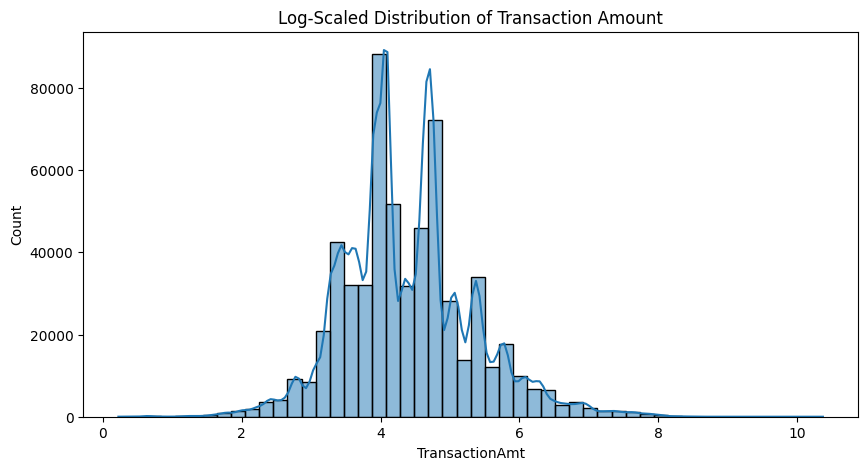

In [ ]:
# Univariate Analysis 1: Distribution of Transaction Amount
df_eda = df.copy()

plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df_eda['TransactionAmt']), bins=50, kde=True)
plt.title('Log-Scaled Distribution of Transaction Amount')
plt.xlabel('TransactionAmt')
plt.ylabel('Count')
plt.show()

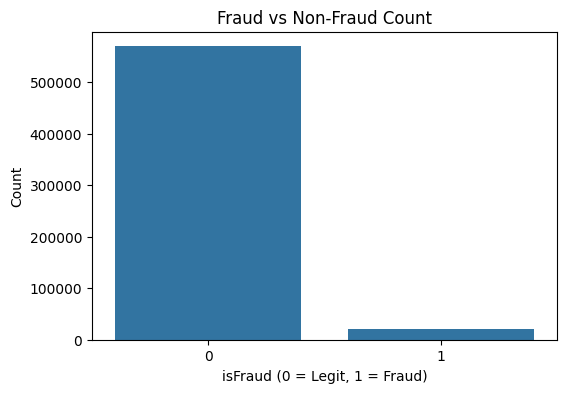

In [ ]:
# Univariate Analysis 2: Fraud v/s Non Fraud Transactions
plt.figure(figsize=(6,4))
sns.countplot(x=df_eda['isFraud'])
plt.title('Fraud vs Non-Fraud Count')
plt.xlabel('isFraud (0 = Legit, 1 = Fraud)')
plt.ylabel('Count')
plt.show()

#### 1.10.2 Bivariate Analysis

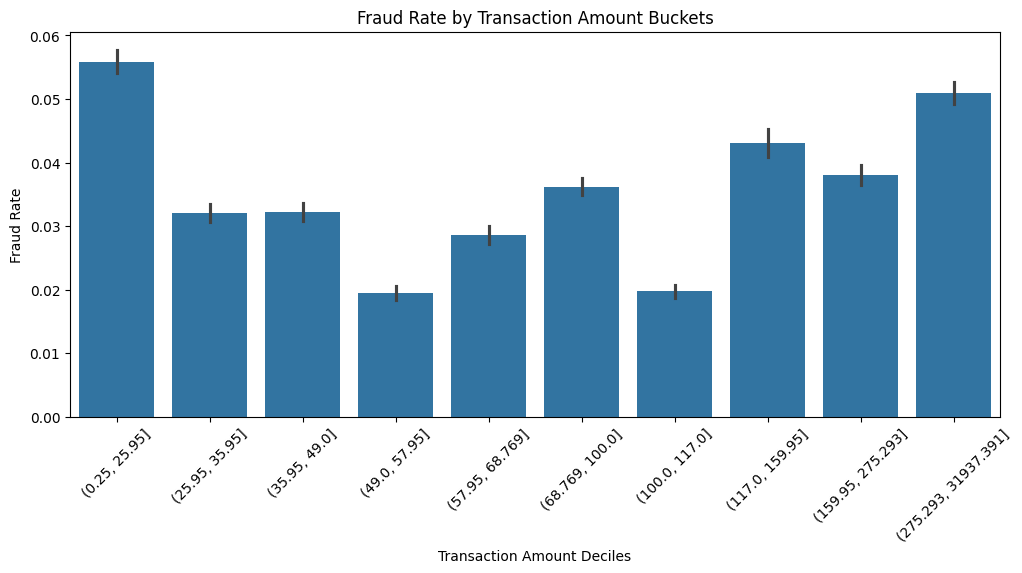

In [ ]:
# Bivariate Analysis 1: Fraud Rate by Transaction Amount
df_eda['Amt_bin'] = pd.qcut(df_eda['TransactionAmt'], q=10, duplicates='drop')

plt.figure(figsize=(12,5))
sns.barplot(x='Amt_bin', y='isFraud', data=df_eda)
plt.xticks(rotation=45)
plt.title('Fraud Rate by Transaction Amount Buckets')
plt.xlabel('Transaction Amount Deciles')
plt.ylabel('Fraud Rate')
plt.show()

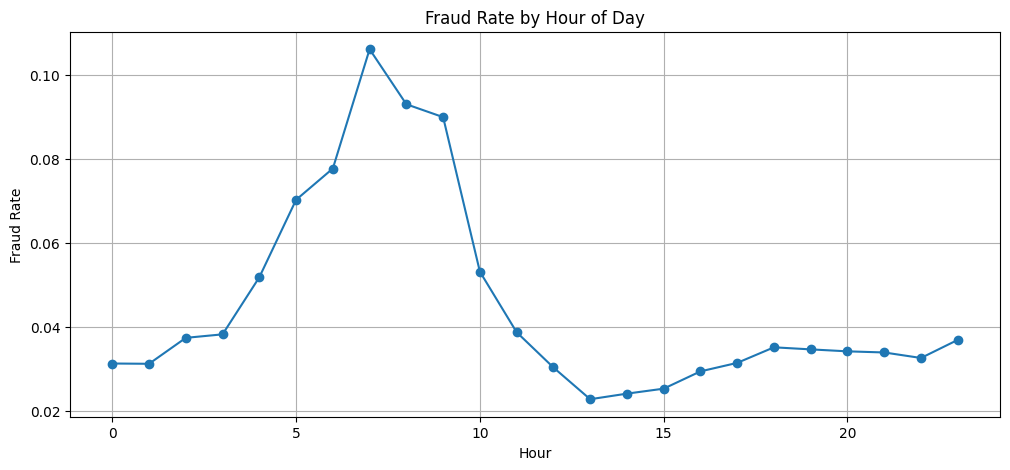

In [ ]:
# Bivariate Analysis 2: Fraud Rate by Hour of Day
hour_fraud = df_eda.groupby('hour')['isFraud'].mean()

plt.figure(figsize=(12,5))
hour_fraud.plot(kind='line', marker='o')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')
plt.grid(True)
plt.show()

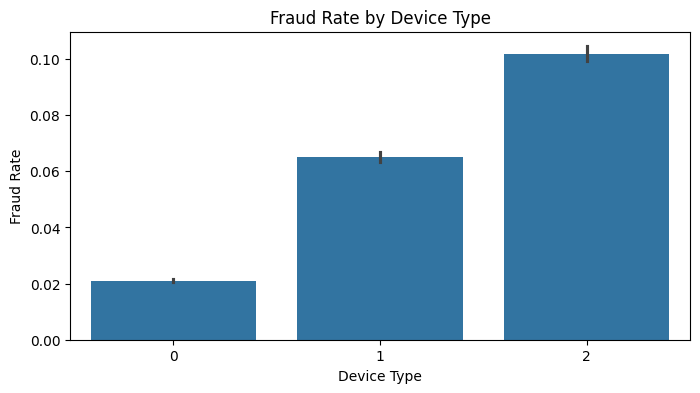

In [ ]:
# Bivariate Analysis 3: Fraud Rate by Device Type
plt.figure(figsize=(8,4))
sns.barplot(x='DeviceType', y='isFraud', data=df_eda)
plt.title('Fraud Rate by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Fraud Rate')
plt.show()

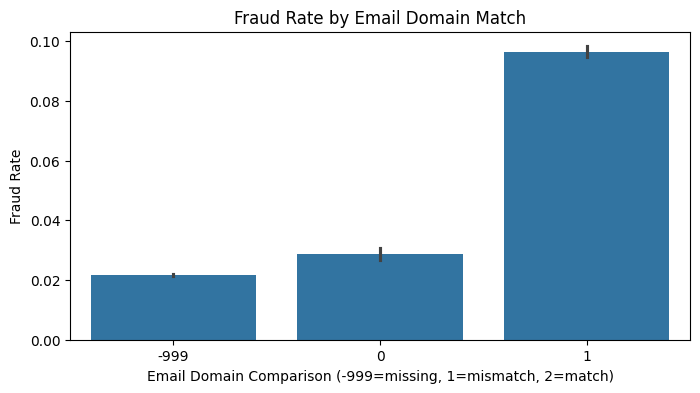

In [ ]:
# Bivariate Analysis 4: Fraud Rate by Email Domain Match
plt.figure(figsize=(8,4))
sns.barplot(x='email_domain_comp', y='isFraud', data=df_eda)
plt.title('Fraud Rate by Email Domain Match')
plt.xlabel('Email Domain Comparison (-999=missing, 1=mismatch, 2=match)')
plt.ylabel('Fraud Rate')
plt.show()

#### 1.10.3 Multivariate Analysis

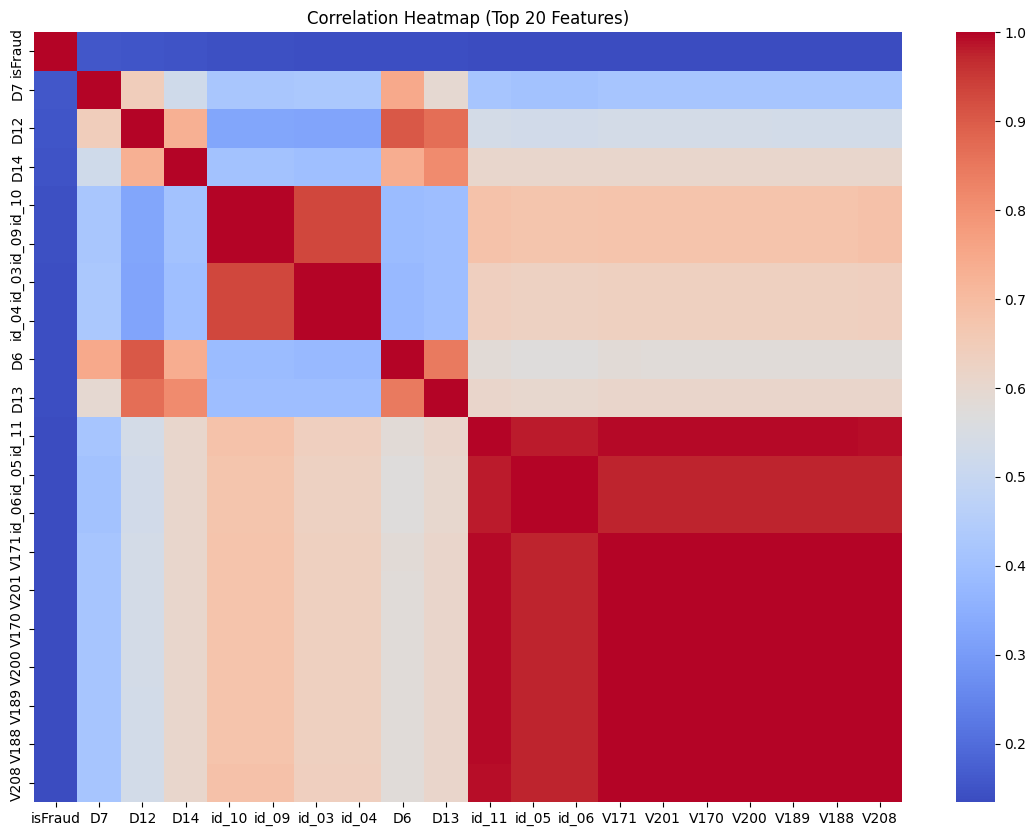

In [ ]:
plt.figure(figsize=(14,10))
corr = df_eda.select_dtypes(include=['float32','int32','int16','int8']).corr()
top_corr = corr['isFraud'].abs().sort_values(ascending=False).head(20).index

sns.heatmap(df_eda[top_corr].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Top 20 Features')
plt.show()

#### Data is now cleaned and inspected, ready for functional analysis (SPRINTS)

# Sprint 1 : To check fraud rate, fraud count, and compare fraud to non‑fraud volumes

Analytics: Descriptive Analytics 

Question: What is the distribution of fraudulent to legitimate transactions across our data?

In [ ]:
# Summary table: fraud vs non-fraud counts
fraud_summary = (
    df
    .groupby("isFraud", dropna=False)
    .agg(
        transaction_count=("TransactionID", "count"),
        average_amount=("TransactionAmt", "mean")
    )
    .reset_index()
)

# Add fraud rate
total_transactions = fraud_summary["transaction_count"].sum()
fraud_count = fraud_summary.loc[fraud_summary["isFraud"] == 1, "transaction_count"].values[0]

fraud_rate = fraud_count / total_transactions * 100

fraud_summary["fraud_rate_percent"] = (
    fraud_summary["transaction_count"] / total_transactions * 100
)

display(fraud_summary)

print(f"Fraud Rate: {fraud_rate:.2f}%")

isFraud,transaction_count,average_amount,fraud_rate_percent
0,569877,134.51166,96.50099908558268
1,20663,149.24477,3.4990009144173126


Fraud Rate: 3.50%


In [ ]:
# Fraud distribution table (sorted)
fraud_distribution = (
    fraud_summary
    .sort_values("transaction_count", ascending=False)
)

display(fraud_distribution)

isFraud,transaction_count,average_amount,fraud_rate_percent
0,569877,134.51166,96.50099908558268
1,20663,149.24477,3.4990009144173126


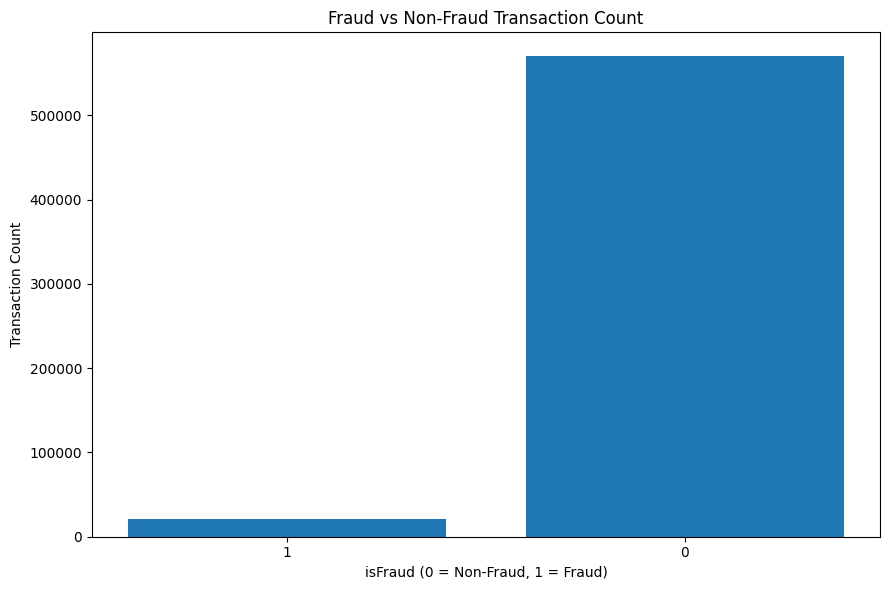

In [ ]:
# Graph 1: Fraud v/s Non-Fraud Count
plot_data = (
    fraud_summary
    .sort_values("transaction_count")
)

plt.figure(figsize=(9, 6))
plt.bar(
    plot_data["isFraud"].astype(str),
    plot_data["transaction_count"]
)
plt.title("Fraud vs Non-Fraud Transaction Count")
plt.xlabel("isFraud (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

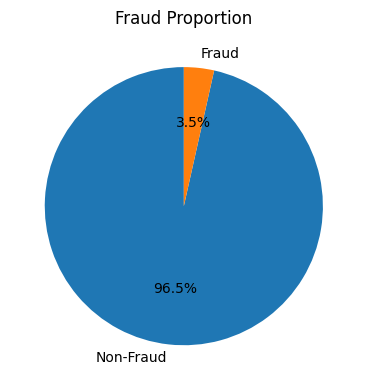

In [ ]:
# Graph 2: Fraud Rate%
labels = ["Non-Fraud", "Fraud"]
sizes = [
    fraud_summary.loc[fraud_summary["isFraud"] == 0, "transaction_count"].values[0],
    fraud_summary.loc[fraud_summary["isFraud"] == 1, "transaction_count"].values[0]
]

plt.figure(figsize=(4, 4))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Fraud Proportion")
plt.tight_layout()
plt.show()


# Sprint 2 : Identifying high‑value fraud patterns and compare amount distributions between fraud and non‑fraud.

Analytics: Descriptive Analytics 

Question: What differences exist between fraud and non‑fraud transaction amounts, and where do fraud spikes occur?  

In [ ]:
# Summary table: fraud vs non-fraud transaction amount statistics
amount_summary = (
    df
    .groupby("isFraud", dropna=False)
    .agg(
        transaction_count=("TransactionID", "count"),
        average_amount=("TransactionAmt", "mean"),
        median_amount=("TransactionAmt", "median"),
        max_amount=("TransactionAmt", "max"),
        min_amount=("TransactionAmt", "min"),
        amount_std=("TransactionAmt", "std")
    )
    .reset_index()
)

# Clean missing std values
amount_summary["amount_std"] = amount_summary["amount_std"].fillna(0)

display(amount_summary)

isFraud,transaction_count,average_amount,median_amount,max_amount,min_amount,amount_std
0,569877,134.51166,68.5,31937.39,0.251,239.39508
1,20663,149.24477,75.0,5191.0,0.292,232.21216


In [ ]:
# Create amount buckets
df["amount_bucket"] = pd.cut(
    df["TransactionAmt"],
    bins=[0, 50, 200, df["TransactionAmt"].max()],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

# Fraud rate by bucket
bucket_summary = (
    df
    .groupby("amount_bucket", dropna=False)
    .agg(
        transaction_count=("TransactionID", "count"),
        fraud_count=("isFraud", "sum"),
        average_amount=("TransactionAmt", "mean")
    )
    .reset_index()
)

bucket_summary["fraud_rate_percent"] = (
    bucket_summary["fraud_count"] / bucket_summary["transaction_count"] * 100
)

display(bucket_summary)

amount_bucket,transaction_count,fraud_count,average_amount,fraud_rate_percent
Low,204524,7833,33.568768,3.829868377305353
Medium,292136,8687,98.452515,2.9736150286168086
High,93880,4143,469.8744,4.413080528334044


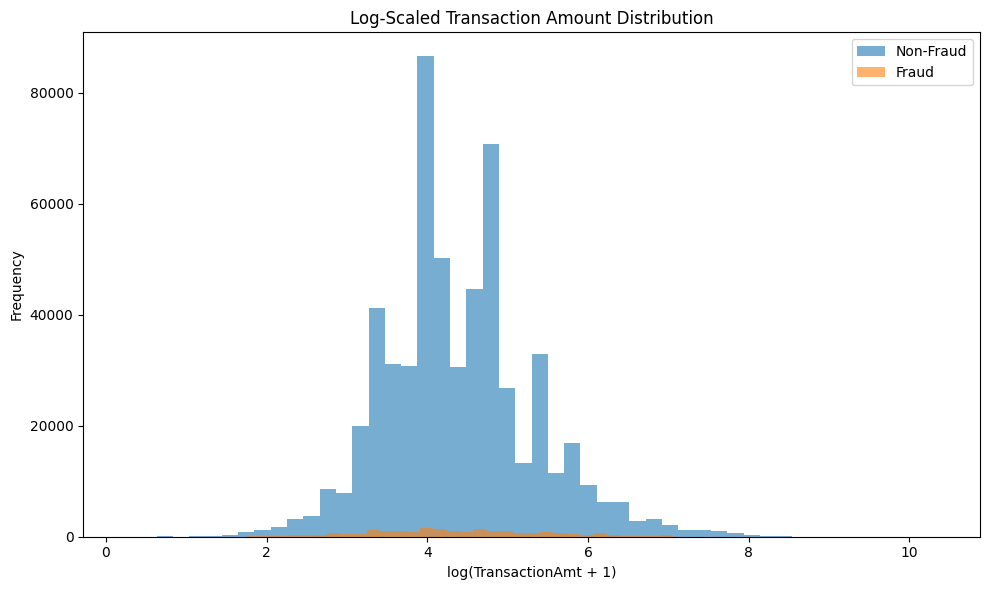

In [ ]:
# Graph 1: Fraud v/s Non-fraud Amount Distribution using log-scale

df["TransactionAmt_log"] = np.log1p(df["TransactionAmt"]) # Log-transform amounts (add 1 to avoid log(0))

fraud_log = df[df["isFraud"] == 1]["TransactionAmt_log"]
nonfraud_log = df[df["isFraud"] == 0]["TransactionAmt_log"]

plt.figure(figsize=(10, 6))
plt.hist(nonfraud_log, bins=50, alpha=0.6, label="Non-Fraud")
plt.hist(fraud_log, bins=50, alpha=0.6, label="Fraud")
plt.title("Log-Scaled Transaction Amount Distribution")
plt.xlabel("log(TransactionAmt + 1)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

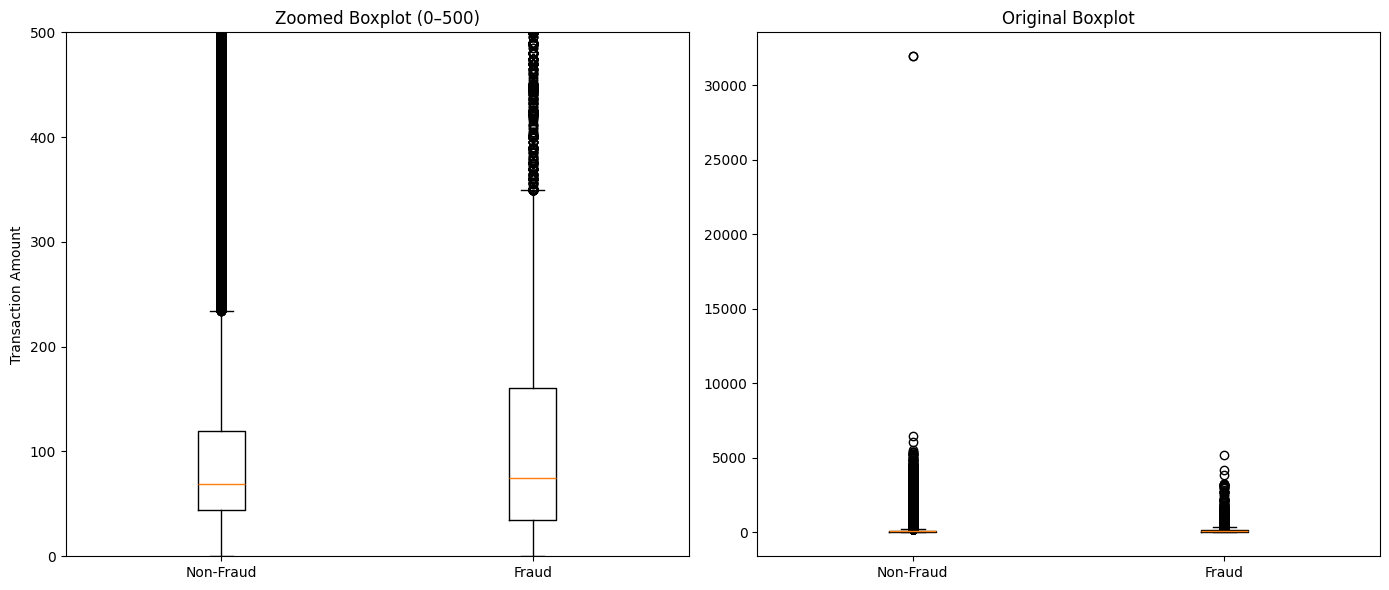

In [ ]:
# Graph 2: Boxplot of Amounts for Fraund and Non-Fraud Transactions

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: boxplot of transactions upto 500
axes[0].boxplot(
    [
        df[df["isFraud"] == 0]["TransactionAmt"],
        df[df["isFraud"] == 1]["TransactionAmt"]
    ],
    labels=["Non-Fraud", "Fraud"],
    showfliers=True
)
axes[0].set_ylim(0, 500)
axes[0].set_title("Zoomed Boxplot (0–500)")
axes[0].set_ylabel("Transaction Amount")

# Subplot 2: Original boxplot
axes[1].boxplot(
    [
        df[df["isFraud"] == 0]["TransactionAmt"],
        df[df["isFraud"] == 1]["TransactionAmt"]
    ],
    labels=["Non-Fraud", "Fraud"],
    showfliers=True
)
axes[1].set_title("Original Boxplot")

plt.tight_layout()
plt.show()

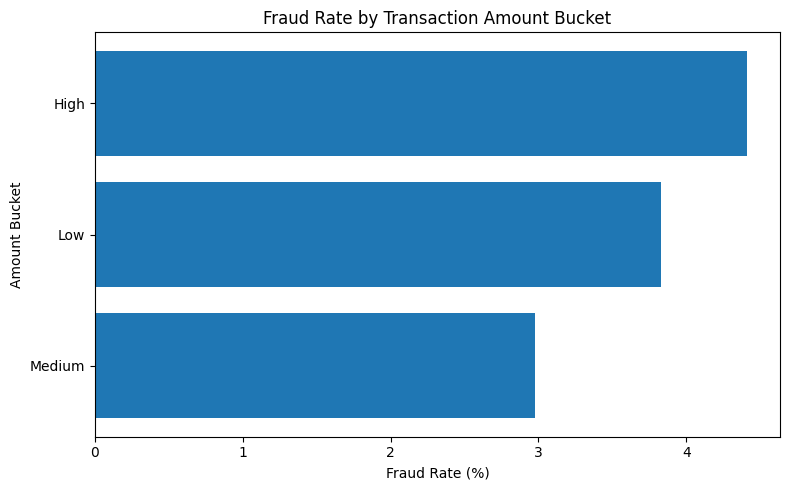

In [ ]:
# Graph 3: Fraud Rate by High, Medium and Low Amounts 
plot_data = bucket_summary.sort_values("fraud_rate_percent")

plt.figure(figsize=(8, 5))
plt.barh(
    plot_data["amount_bucket"].astype(str),
    plot_data["fraud_rate_percent"]
)
plt.title("Fraud Rate by Transaction Amount Bucket")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Amount Bucket")
plt.tight_layout()
plt.show()

# Sprint 3 : Detect hourly fraud spikes and identify suspicious time windows.

Analytics: Descriptive Analytics 

Question: What hours of the day experience the highest frequency of fraud?  

In [ ]:
# Convert TransactionDT into datetime (if needed)
df["TransactionDT_datetime"] = pd.to_datetime(df["TransactionDT"], unit="s", origin="unix")

# Extract hour
df["hour"] = df["TransactionDT_datetime"].dt.hour

# Summary table
hour_summary = (
    df
    .groupby("hour", dropna=False)
    .agg(
        transaction_count=("TransactionID", "count"),
        fraud_count=("isFraud", "sum"),
        average_amount=("TransactionAmt", "mean")
    )
    .reset_index()
)

# Fraud rate
hour_summary["fraud_rate_percent"] = (
    hour_summary["fraud_count"] / hour_summary["transaction_count"] * 100
)

display(hour_summary)

hour,transaction_count,fraud_count,average_amount,fraud_rate_percent
0,37795,1186,123.30987,3.1379812144463552
1,32797,1027,116.02845,3.131383968045858
2,26732,1002,111.3322,3.7483166242705375
3,20802,797,106.60173,3.83136236900298
4,14839,770,102.96102,5.1890289103039295
5,9701,682,105.26336,7.0302030718482635
6,6007,467,105.718765,7.774263359414017
7,3704,393,113.857,10.610151187904968
8,2591,241,125.43931,9.301428020069471
9,2479,223,144.51666,8.99556272690601


In [ ]:
# Identify the peak hours for fraud
peak_fraud_hours = (
    hour_summary
    .sort_values("fraud_rate_percent", ascending=False)
    .head(10)
)

display(peak_fraud_hours)

hour,transaction_count,fraud_count,average_amount,fraud_rate_percent
7,3704,393,113.857,10.610151187904968
8,2591,241,125.43931,9.301428020069471
9,2479,223,144.51666,8.99556272690601
6,6007,467,105.718765,7.774263359414017
5,9701,682,105.26336,7.0302030718482635
10,3627,193,132.43596,5.321202095395644
4,14839,770,102.96102,5.1890289103039295
11,6827,265,122.97901,3.8816464039841807
3,20802,797,106.60173,3.83136236900298
2,26732,1002,111.3322,3.7483166242705375


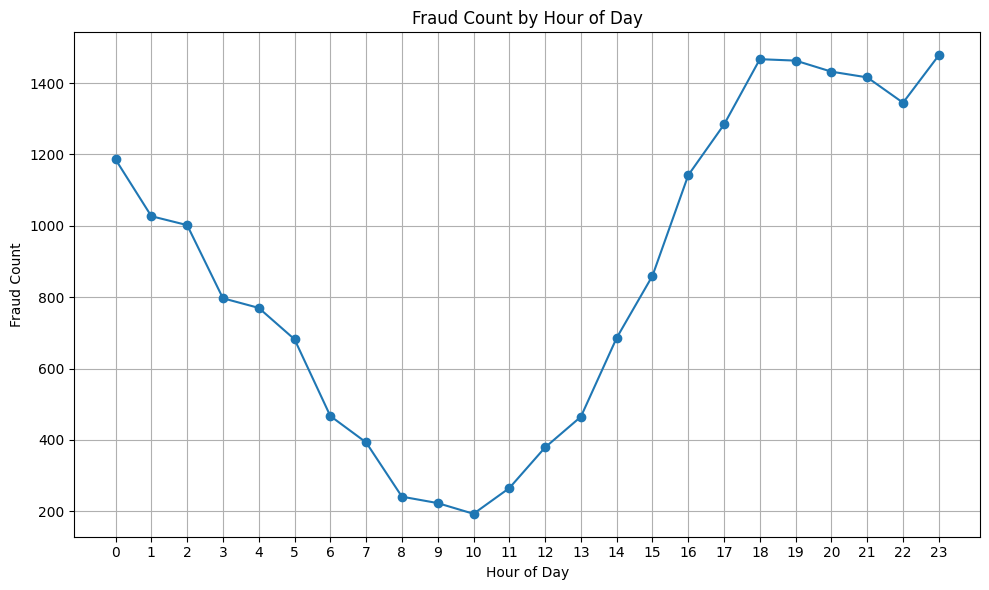

In [ ]:
# Graph 1: Fraud count by Hour of Day
plot_data = hour_summary.sort_values("hour")

plt.figure(figsize=(10, 6))
plt.plot(
    plot_data["hour"],
    plot_data["fraud_count"],
    marker="o"
)
plt.title("Fraud by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Count")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

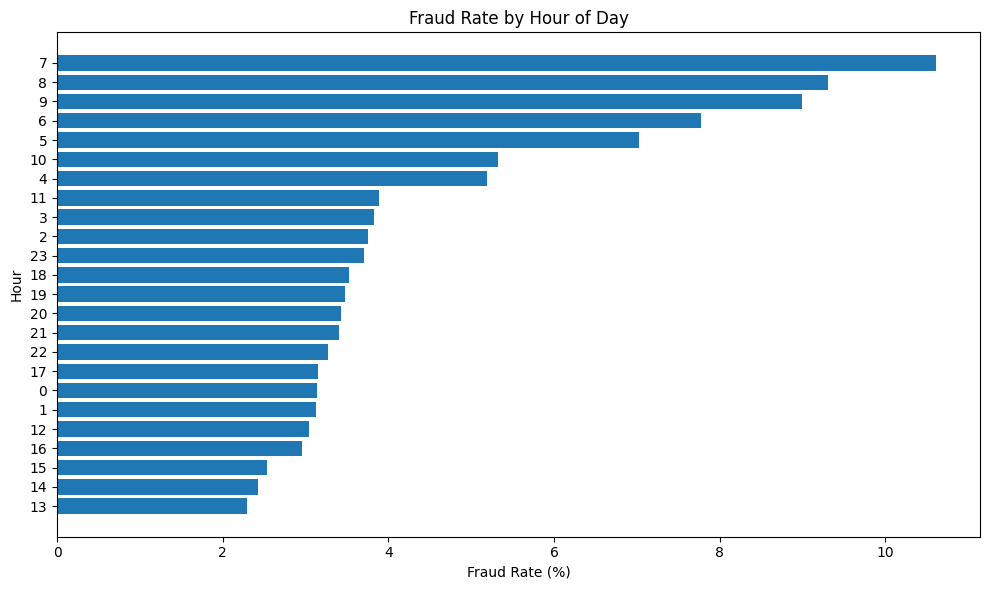

In [ ]:
# Graph 2: Fraud Rate by Hour of Day
plot_data = hour_summary.sort_values("fraud_rate_percent")

plt.figure(figsize=(10, 6))
plt.barh(
    plot_data["hour"].astype(str),
    plot_data["fraud_rate_percent"]
)
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Hour")
plt.tight_layout()
plt.show()

# Sprint 4 : Identify regions at high‑risk and investigate geographic fraud clusters.

Analytics: Diagnostic Analytics 

Question: Why do certain geographic regions have higher fraud rates and abnormal fraud patterns?

In [ ]:
# Summary table for geogrpahic investigation
region_summary = (
    df
    .groupby("addr1", dropna=False)
    .agg(
        transaction_count=("TransactionID", "count"),
        fraud_count=("isFraud", "sum"),
        average_amount=("TransactionAmt", "mean"),
        amount_std=("TransactionAmt", "std")
    )
    .reset_index()
)

# Clean missing std values
region_summary["amount_std"] = region_summary["amount_std"].fillna(0)

# Fraud rate
region_summary["fraud_rate_percent"] = (
    region_summary["fraud_count"] / region_summary["transaction_count"] * 100
)

display(region_summary)

addr1,transaction_count,fraud_count,average_amount,amount_std,fraud_rate_percent
0,26,0,51.768963,33.78731,0.0
1,1,0,50.838,0.0,0.0
2,13,0,25.410383,15.246586,0.0
3,8,0,94.1875,81.45899,0.0
4,3,0,56.3,52.56774,0.0
5,20,0,199.5745,181.82626,0.0
6,3220,64,125.61263,189.10083,1.9875776397515528
7,2,0,17.548,0.0,0.0
8,2,0,14.808,0.0,0.0
9,1,0,49.0,0.0,0.0


In [ ]:
# Identify the top 10 regions with the highest fraud rates
high_risk_regions = (
    region_summary
    .sort_values("fraud_rate_percent", ascending=False)
    .head(10)
)

display(high_risk_regions)

addr1,transaction_count,fraud_count,average_amount,amount_std,fraud_rate_percent
157,9,6,4.6800003,6.460048,66.66666666666666
288,23,13,82.95226,55.216778,56.52173913043478
279,2,1,57.643,41.94416,50.0
301,4,2,68.6545,21.748636,50.0
274,2,1,11.5185,1.849084,50.0
222,35,16,75.36832,43.587135,45.714285714285715
248,38,13,31.144894,27.038649,34.21052631578947
124,6,2,1003.4167,1272.3822,33.33333333333333
249,38,11,183.94737,197.50525,28.947368421052634
87,54,13,51.817608,58.074127,24.074074074074073


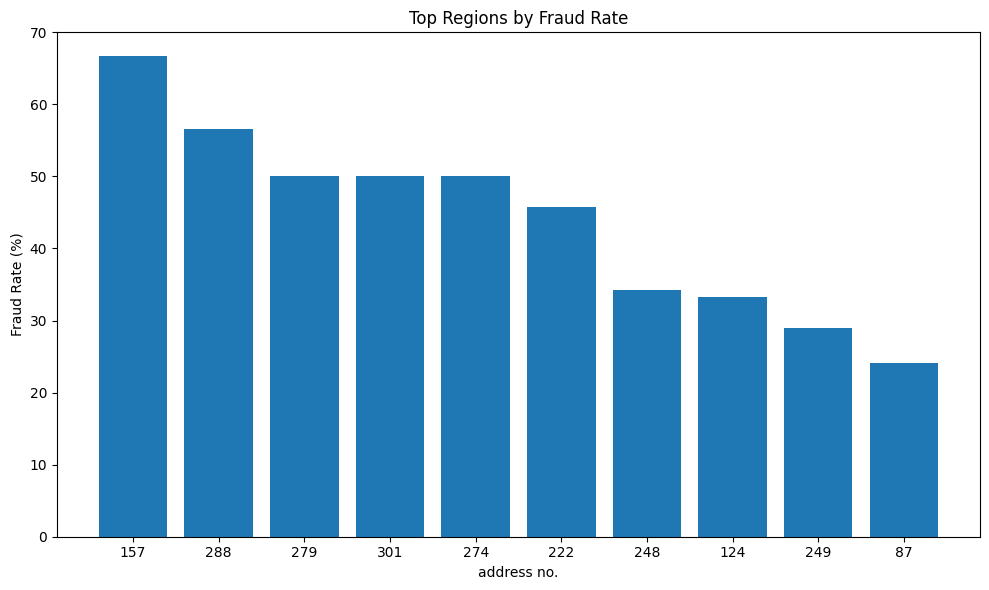

In [ ]:
# Graph 1: Top 10 regions by fraud rate
plot_data = (
    region_summary
    .sort_values("fraud_rate_percent", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.bar(
    plot_data["addr1"].astype(str),
    plot_data["fraud_rate_percent"]
)
plt.title("Top Regions by Fraud Rate")
plt.xlabel("Address no.")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

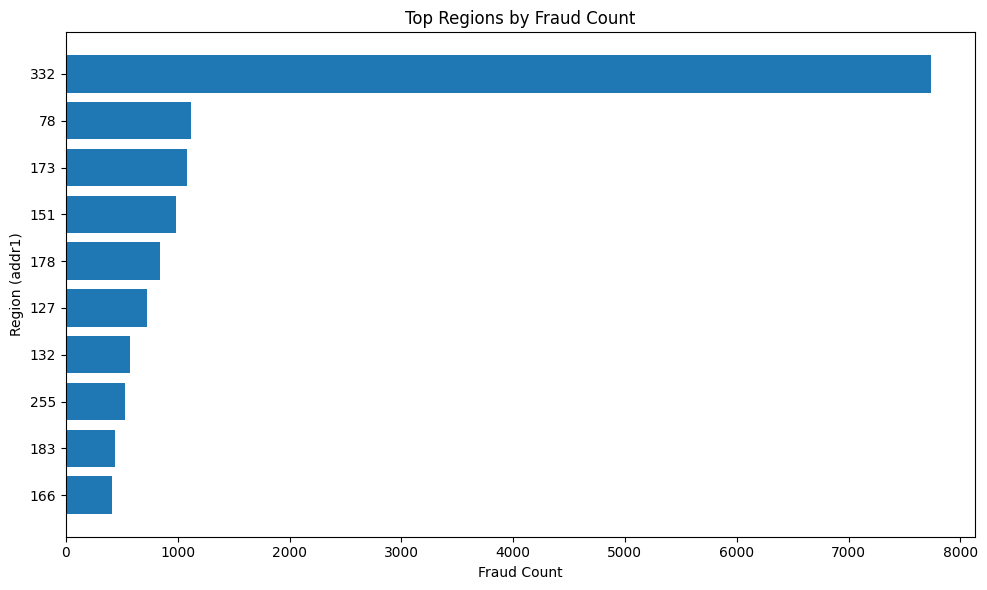

In [ ]:
# Graph 2: Top 10 regions by fraud count
plot_data = (
    region_summary
    .sort_values("fraud_count", ascending=False)
    .head(10)
    .sort_values("fraud_count")
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_data["addr1"].astype(str),
    plot_data["fraud_count"]
)
plt.title("Top Regions by Fraud Count")
plt.xlabel("Fraud Count")
plt.ylabel("Region (addr1)")
plt.tight_layout()
plt.show()

# Sprint 5 : Detect device‑sharing fraud rings and suspicious device clusters.

Analytics: Diagnostic Analytics 

Question: Why do certain devices show abnormal fraud behavior, and why is device uniqueness associated with higher fraud risk?

In [ ]:
# Summary table for device investigation
device_summary = (
    df
    .groupby("DeviceInfo", dropna=False)
    .agg(
        transaction_count=("TransactionID", "count"),
        fraud_count=("isFraud", "sum"),
        average_amount=("TransactionAmt", "mean"),
        device_uniqueness=("device_uid_nunique", "mean")
    )
    .reset_index()
)

# Fraud rate
device_summary["fraud_rate_percent"] = (
    device_summary["fraud_count"] / device_summary["transaction_count"] * 100
)

display(device_summary)

DeviceInfo,transaction_count,fraud_count,average_amount,device_uniqueness,fraud_rate_percent
0,1,0,100.0,1.0,0.0
1,1,0,150.0,1.0,0.0
2,4,2,41.377502,1.5,50.0
3,1,0,27.284,1.0,0.0
4,1,0,100.0,1.0,0.0
5,6,0,51.666668,1.6666666666666667,0.0
6,4,0,35.10025,1.0,0.0
7,2,0,37.5,1.0,0.0
8,1,0,25.86,1.0,0.0
9,2,0,14.0789995,2.0,0.0


In [ ]:
# Identify the top 50 suspicious devices
suspicious_devices = (
    device_summary
    .sort_values("fraud_rate_percent", ascending=False)
    .head(50)
)

display(suspicious_devices)

DeviceInfo,transaction_count,fraud_count,average_amount,device_uniqueness,fraud_rate_percent
315,12,12,32.968998,4.666666666666667,100.0
1089,3,3,33.814,3.0,100.0
810,10,10,74.39641,7.0,100.0
813,1,1,50.0,1.0,100.0
824,11,11,81.72082,6.0,100.0
1718,1,1,60.0,1.0,100.0
1541,2,2,62.032,2.0,100.0
1128,3,3,35.044,2.0,100.0
1569,34,34,21.866648,13.0,100.0
235,4,4,6.578,3.0,100.0


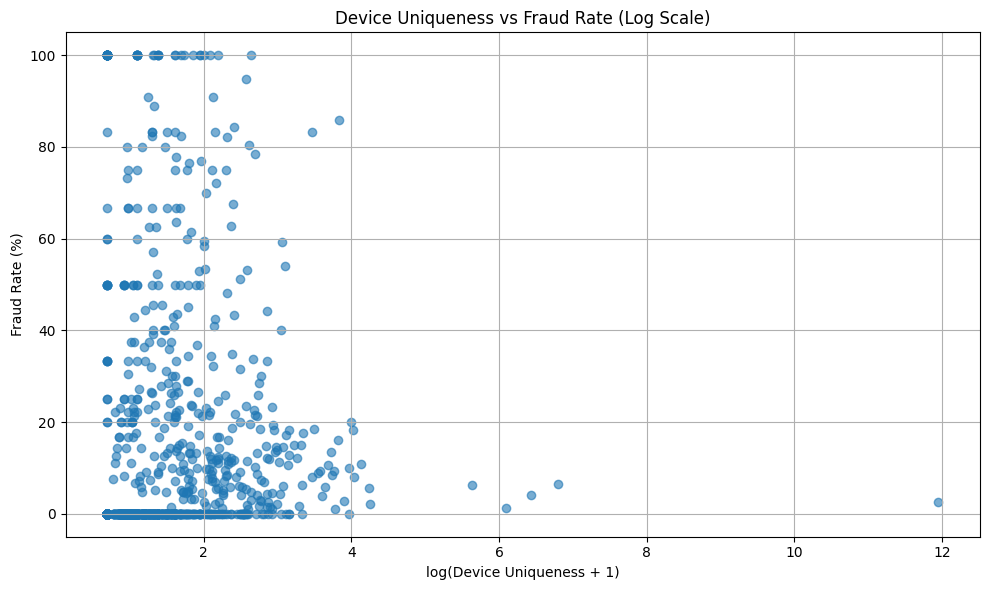

In [ ]:
# Graph 1: Device Uniqueness v/s Fraud Rate

# Log-transform uniqueness (add 1 to avoid log(0))
device_summary["uniqueness_log"] = np.log1p(device_summary["device_uniqueness"])

plt.figure(figsize=(10, 6))
plt.scatter(
    device_summary["uniqueness_log"],
    device_summary["fraud_rate_percent"],
    alpha=0.6
)
plt.title("Device Uniqueness vs Fraud Rate (Log Scale)")
plt.xlabel("log(Device Uniqueness + 1)")
plt.ylabel("Fraud Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

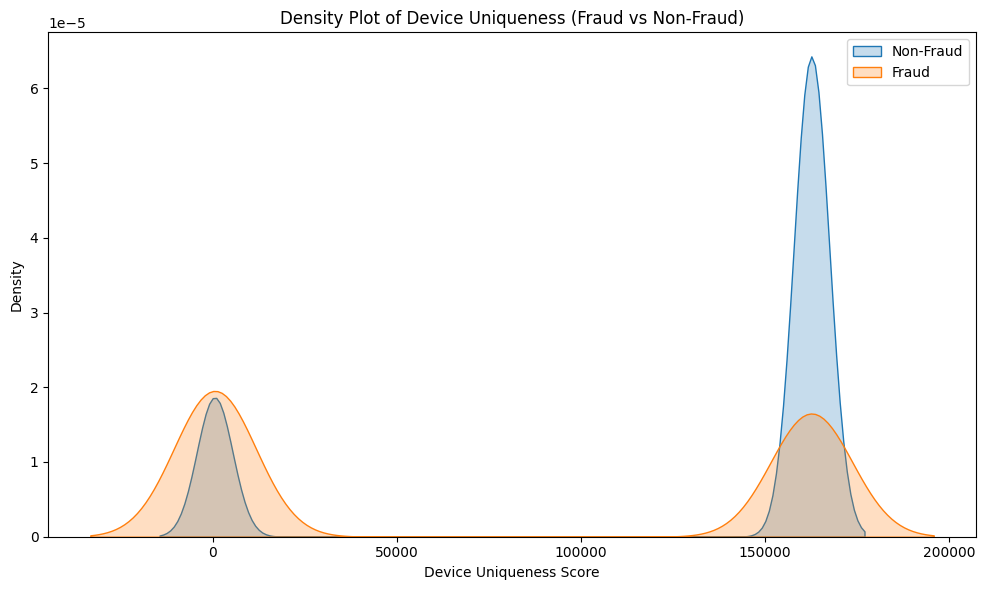

In [ ]:
# Graph 2: Show the difference between fraud devices from normal/Non-fraud devices
plt.figure(figsize=(10, 6))
sns.kdeplot(
    df[df["isFraud"] == 0]["device_uid_nunique"],
    label="Non-Fraud",
    shade=True
)
sns.kdeplot(
    df[df["isFraud"] == 1]["device_uid_nunique"],
    label="Fraud",
    shade=True
)
plt.title("Density Plot of Device Uniqueness (Fraud vs Non-Fraud)")
plt.xlabel("Device Uniqueness Score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

### Note: Find Predictive and Prescriptive Feature Sprints towards the end of Modeliing

# **2. MODELING**

Load clean data

In [45]:
X = pd.read_pickle('X_clean.pkl')
y = pd.read_pickle('y_clean.pkl')['isFraud']


**Train/Test split: TEMPORAL SPLIT (70 / 15 / 15)**
- train   : first 70% rows  → model fitting + early stopping
- val     : next  15% rows  → early stopping monitor (no threshold optim here)
- test    : last  15% rows  → threshold optimization + all reported numbers

In [46]:



n = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train = X.iloc[:n_train].copy()
y_train = y.iloc[:n_train].copy()

X_val   = X.iloc[n_train : n_train + n_val].copy()
y_val   = y.iloc[n_train : n_train + n_val].copy()

X_test  = X.iloc[n_train + n_val :].copy()
y_test  = y.iloc[n_train + n_val :].copy()

print(f"Train : {X_train.shape}  fraud={y_train.mean():.3%}")
print(f"Val   : {X_val.shape}   fraud={y_val.mean():.3%}")
print(f"Test  : {X_test.shape}  fraud={y_test.mean():.3%}")


Train : (413378, 442)  fraud=3.517%
Val   : (88581, 442)   fraud=3.434%
Test  : (88581, 442)  fraud=3.480%


OPTIMIZE RAM (applied per-split after temporal split)

In [47]:
# Convert float64/int64 -> float32/int32 for each split to save RAM
# (Must be done after split so dtypes are applied correctly to all three)
gc.collect()

for _df in [X_train, X_val, X_test]:
    for col in _df.columns:
        if _df[col].dtype == 'float64':
            _df[col] = _df[col].astype('float32')
        elif _df[col].dtype == 'int64':
            _df[col] = _df[col].astype('int32')

print(f"X_train RAM: {X_train.memory_usage(deep=True).sum() / 1024**3:.3f} GB")
print(f"X_val   RAM: {X_val.memory_usage(deep=True).sum()   / 1024**3:.3f} GB")
print(f"X_test  RAM: {X_test.memory_usage(deep=True).sum()  / 1024**3:.3f} GB")


X_train RAM: 0.680 GB
X_val   RAM: 0.146 GB
X_test  RAM: 0.146 GB


Handle "unseen" categories between train/test.

Only keep categorical values that appear in BOTH train and the real test set. A category that only appears on one side -> replaced with -999 (avoids the model skewing toward it)

In [48]:
# Any value in val/test not seen in train -> -999 (unknown).

active_cat_columns = [c for c in cat_columns if c in X_train.columns]  

for column in active_cat_columns:
    train_set = set(X_train[column])

    X_train[column] = X_train[column].map(lambda x: x if x in train_set else -999)
    X_val[column]   = X_val[column].map(lambda x: x if x in train_set else -999)
    X_test[column]  = X_test[column].map(lambda x: x if x in train_set else -999)

**MODEL 1: LightGBM**


In [49]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=2000,          
    learning_rate=0.02,
    num_leaves=64,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_samples=20,
    min_split_gain=0.001,
    random_state=42
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],  
    eval_metric='auc',
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)

# Predict on val (for model comparison) and test (for threshold optimization)
lgb_pred_val  = lgb_model.predict_proba(X_val)[:, 1]
lgb_pred_test = lgb_model.predict_proba(X_test)[:, 1]

lgb_auc_val  = roc_auc_score(y_val,  lgb_pred_val)
lgb_auc_test = roc_auc_score(y_test, lgb_pred_test)
print(f'LightGBM AUC (val) : {lgb_auc_val:.4f}')
print(f'LightGBM AUC (test): {lgb_auc_test:.4f}')




c:\Users\phamt\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14538, number of negative: 398840
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.624847 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 34897
[LightGBM] [Info] Number of data points in the train set: 413378, number of used features: 440
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035169 -> initscore=-3.311794
[LightGBM] [Info] Start training from score -3.311794
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.907689	valid_0's binary_logloss: 0.0888818
[400]	valid_0's auc: 0.923741	valid_0's binary_logloss: 0.0828214
[600]	valid_0's auc: 0.929166	valid_0's binary_logloss: 0.0806378
[800]	valid_0's auc: 0.931502	valid_0's binary_logloss: 0.0793496
[1000]	valid_0's auc: 0.933773	valid_0's binary_logloss: 0.0782381
[1200]	valid_0's auc: 0.934883	valid_0's binary_logloss: 0.0775896
[1400]	valid_0's auc: 0.935321	valid_0's b

In [50]:
lgb_pred = lgb_pred_val
lgb_auc  = lgb_auc_val

In [36]:
comparison = pd.DataFrame({
    'isFraud_actual': y_val.values,
    'predict_proba': lgb_pred_val,
    'isFraud_predicted': (lgb_pred_val >= 0.5).astype(int)
})

# Correct predictions
correct = comparison[comparison['isFraud_actual'] == comparison['isFraud_predicted']]
print("CORRECT predictions (sample)")
print(correct.sample(10, random_state=42))

# Wrong predictions
wrong = comparison[comparison['isFraud_actual'] != comparison['isFraud_predicted']]
print(f"\nWRONG predictions ")
print(wrong.sample(min(10, len(wrong)), random_state=42))

CORRECT predictions (sample)
       isFraud_actual  predict_proba  isFraud_predicted
40004               0       0.023941                  0
975                 0       0.002545                  0
84589               0       0.001074                  0
60061               0       0.010073                  0
77787               0       0.005138                  0
21779               0       0.004633                  0
6576                0       0.002798                  0
69828               0       0.032292                  0
83666               0       0.021737                  0
5051                0       0.007688                  0

WRONG predictions 
       isFraud_actual  predict_proba  isFraud_predicted
59509               1       0.014825                  0
28891               1       0.491273                  0
22885               1       0.303780                  0
62187               1       0.235314                  0
25350               1       0.003502                  0

In [37]:
print(classification_report(y_val, (lgb_pred_val >= 0.5).astype(int)))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     85539
           1       0.87      0.40      0.54      3042

    accuracy                           0.98     88581
   macro avg       0.93      0.70      0.77     88581
weighted avg       0.98      0.98      0.97     88581



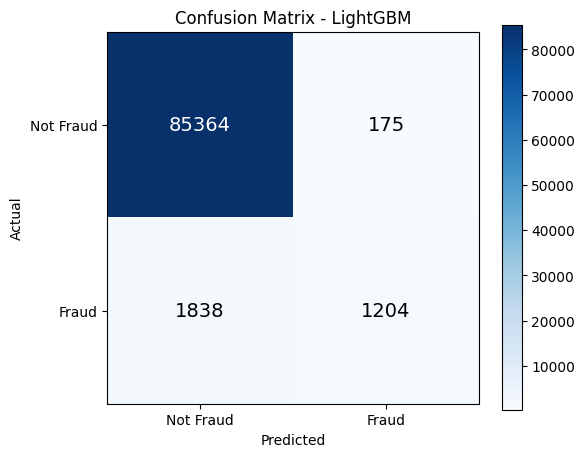

In [38]:
lgb_pred_binary = (lgb_pred_val >= 0.5).astype(int)
cm = confusion_matrix(y_val, lgb_pred_binary)

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, cmap='Blues')

labels = ['Not Fraud', 'Fraud']
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - LightGBM')

# Annotate each cell with its count
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)

plt.colorbar(im)
plt.show()

**MODEL 2: CatBoost**

In [39]:
cat_model = cb.CatBoostClassifier(
    iterations=2000,            
    learning_rate=0.03,
    depth=8,
    eval_metric='AUC',
    random_state=42,
    verbose=200
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),    # only val set for early stopping
    early_stopping_rounds=100
)

cat_pred_val  = cat_model.predict_proba(X_val)[:, 1]
cat_pred_test = cat_model.predict_proba(X_test)[:, 1]

cat_auc_val  = roc_auc_score(y_val,  cat_pred_val)
cat_auc_test = roc_auc_score(y_test, cat_pred_test)
print(f'CatBoost AUC (val) : {cat_auc_val:.4f}')
print(f'CatBoost AUC (test): {cat_auc_test:.4f}')




0:	test: 0.6742910	best: 0.6742910 (0)	total: 495ms	remaining: 16m 28s
200:	test: 0.8737588	best: 0.8737588 (200)	total: 1m 5s	remaining: 9m 41s
400:	test: 0.8844593	best: 0.8844593 (400)	total: 2m 9s	remaining: 8m 34s
600:	test: 0.8905764	best: 0.8905764 (600)	total: 3m 11s	remaining: 7m 26s
800:	test: 0.8960315	best: 0.8960315 (800)	total: 4m 12s	remaining: 6m 18s
1000:	test: 0.9009665	best: 0.9009708 (998)	total: 5m 14s	remaining: 5m 13s
1200:	test: 0.9052510	best: 0.9052510 (1200)	total: 6m 16s	remaining: 4m 10s
1400:	test: 0.9093937	best: 0.9093937 (1400)	total: 7m 18s	remaining: 3m 7s
1600:	test: 0.9122115	best: 0.9122346 (1589)	total: 8m 24s	remaining: 2m 5s
1800:	test: 0.9143847	best: 0.9143888 (1798)	total: 9m 30s	remaining: 1m 3s
1999:	test: 0.9159237	best: 0.9159305 (1996)	total: 10m 38s	remaining: 0us

bestTest = 0.9159305122
bestIteration = 1996

Shrink model to first 1997 iterations.
CatBoost AUC (val) : 0.9159
CatBoost AUC (test): 0.9016


In [40]:
cat_pred = cat_pred_val
cat_auc  = cat_auc_val

In [41]:
cat_pred_binary = (cat_pred_val >= 0.5).astype(int)

comparison_cat = pd.DataFrame({
    'isFraud_actual': y_val.values,
    'predicted_probability': cat_pred,
    'isFraud_predicted': cat_pred_binary
})

# Correct predictions
correct_cat = comparison_cat[comparison_cat['isFraud_actual'] == comparison_cat['isFraud_predicted']]
print("CORRECT predictions (sample)")
print(correct_cat.sample(10, random_state=42))

# Wrong predictions
wrong_cat = comparison_cat[comparison_cat['isFraud_actual'] != comparison_cat['isFraud_predicted']]
print(f"\nWRONG predictions (total {len(wrong_cat)} rows)")
print(wrong_cat.sample(min(10, len(wrong_cat)), random_state=42)) 

CORRECT predictions (sample)
       isFraud_actual  predicted_probability  isFraud_predicted
86026               0               0.011832                  0
13568               0               0.013653                  0
72422               0               0.003817                  0
49003               0               0.035620                  0
79576               0               0.003601                  0
38187               0               0.005290                  0
58050               0               0.003301                  0
5758                0               0.014583                  0
79403               0               0.006348                  0
23627               0               0.001475                  0

WRONG predictions (total 2032 rows)
       isFraud_actual  predicted_probability  isFraud_predicted
34719               1               0.011761                  0
45328               1               0.068419                  0
28938               1               0.

In [42]:
from sklearn.metrics import confusion_matrix, classification_report

cm_cat = confusion_matrix(y_val, cat_pred_binary)
print("Confusion Matrix:")
print(cm_cat)

print(classification_report(y_val, cat_pred_binary))

Confusion Matrix:
[[85368   171]
 [ 1861  1181]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     85539
           1       0.87      0.39      0.54      3042

    accuracy                           0.98     88581
   macro avg       0.93      0.69      0.76     88581
weighted avg       0.98      0.98      0.97     88581



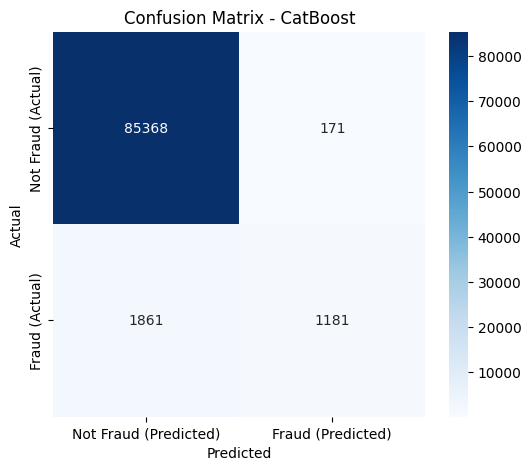

In [43]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud (Predicted)', 'Fraud (Predicted)'],
            yticklabels=['Not Fraud (Actual)', 'Fraud (Actual)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - CatBoost')
plt.show()

**MODEL 3: Neural Network (MLP)**

In [40]:
def build_model(input_dim):
    model = Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

nn_model = build_model(X_train.shape[1])

early_stop = EarlyStopping(monitor='val_AUC', mode='max', patience=5, restore_best_weights=True)

nn_model.fit(
    X_train_scaled, y_train.values,            
    validation_data=(X_val_scaled, y_val.values),
    epochs=20,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - AUC: 0.8243 - loss: 0.1208 - val_AUC: 0.8300 - val_loss: 0.6557
Epoch 2/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - AUC: 0.8595 - loss: 0.1075 - val_AUC: 0.8349 - val_loss: 1.2548
Epoch 3/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - AUC: 0.8694 - loss: 0.1031 - val_AUC: 0.8399 - val_loss: 1.3518
Epoch 4/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - AUC: 0.8755 - loss: 0.1000 - val_AUC: 0.8437 - val_loss: 2.2345
Epoch 5/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - AUC: 0.8827 - loss: 0.0968 - val_AUC: 0.8451 - val_loss: 1.2845
Epoch 6/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - AUC: 0.8882 - loss: 0.0942 - val_AUC: 0.8410 - val_loss: 1.5235
Epoch 7/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - AUC: 0.8919 - loss: 0.0925 - val_AUC: 0.8435 - val_loss: 1.3596
Epoch 8/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - AUC: 0.8959 - loss: 0.0909 - val_AUC: 0.8356 - val_loss: 0.7041
Epoch 9/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 

In [41]:
nn_pred_val  = nn_model.predict(X_val_scaled).reshape(-1)
nn_pred_test = nn_model.predict(X_test_scaled).reshape(-1)

nn_auc_val  = roc_auc_score(y_val,  nn_pred_val)
nn_auc_test = roc_auc_score(y_test, nn_pred_test)
print(f'Neural Network AUC (val) : {nn_auc_val:.4f}')
print(f'Neural Network AUC (test): {nn_auc_test:.4f}')




2769/2769 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
2769/2769 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
Neural Network AUC (val) : 0.8440
Neural Network AUC (test): 0.8343


In [42]:
nn_pred = nn_pred_val
nn_auc  = nn_auc_val

In [43]:
nn_pred_binary = (nn_pred_val >= 0.5).astype(int)

**Confusion Matrix + Classification Report**


In [44]:
cm_nn = confusion_matrix(y_val, nn_pred_binary)


print(classification_report(y_val, nn_pred_binary))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     85539
           1       0.58      0.31      0.40      3042

    accuracy                           0.97     88581
   macro avg       0.78      0.65      0.69     88581
weighted avg       0.96      0.97      0.96     88581



**Visualize Confusion Matrix**

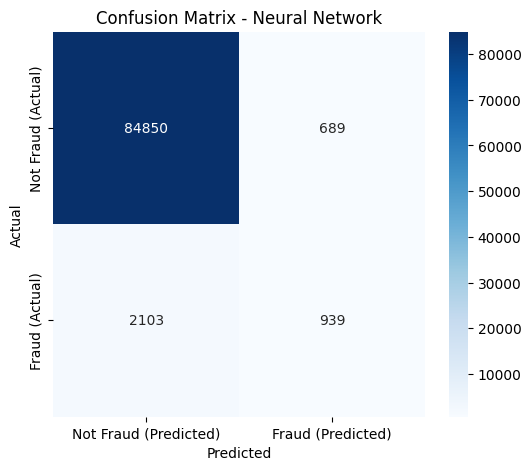

In [45]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud (Predicted)', 'Fraud (Predicted)'],
            yticklabels=['Not Fraud (Actual)', 'Fraud (Actual)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Neural Network')
plt.show()

**AUC Comparision accross 3 models**

In [46]:

print(f'LightGBM        : {lgb_auc:.4f}')
print(f'CatBoost        : {cat_auc:.4f}')
print(f'Neural Network  : {nn_auc:.4f}')

LightGBM        : 0.9355
CatBoost        : 0.9159
Neural Network  : 0.8440


**AUC Visualization accross 3 models**

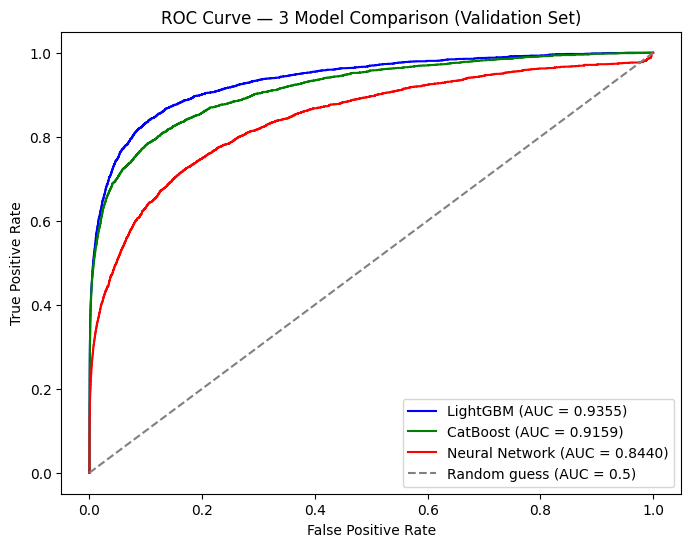

In [47]:
# ROC curves — compare on validation set (same held-out period for all 3 models)
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, lgb_pred_val)
fpr_cat, tpr_cat, _ = roc_curve(y_val, cat_pred_val)
fpr_nn,  tpr_nn,  _ = roc_curve(y_val, nn_pred_val)

auc_lgb = auc(fpr_lgb, tpr_lgb)
auc_cat = auc(fpr_cat, tpr_cat)
auc_nn  = auc(fpr_nn,  tpr_nn)

plt.figure(figsize=(8,6))
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:.4f})', color='blue')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {auc_cat:.4f})', color='green')
plt.plot(fpr_nn,  tpr_nn,  label=f'Neural Network (AUC = {auc_nn:.4f})', color='red')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — 3 Model Comparison (Validation Set)')
plt.legend()
plt.show()



- LightGBM: AUC = 0.9355 (best): curve hugs the top-left corner closest, 
  indicating the strongest separation between fraud and non-fraud.
- CatBoost: AUC = 0.9159: solid performance, but noticeably behind LightGBM.
- Neural Network: AUC = 0.8474 (lowest): expected, since tree-based models 
  typically outperform NNs on tabular data, especially with no scaling 
  applied to id-based categorical values.

All 3 models clearly outperform random guessing (AUC = 0.5, dashed line).

**Note:** But AUC alone doesn't tell the full story. This is exactly why threshold selection matters more than 
raw AUC for this business problem, and will be addressed in the 
cost-based threshold optimization step.

**Selected model: LightGBM**: highest AUC, used going forward for the 
business cost function and threshold optimization.

**Feature Importance: LightGBM**

Because many V-columns are masked/anonymized, we cannot interpret them manually.
The feature importance plot below reveals *which* anonymous features the model relies on most,
directly addressing the "data privacy / blind spot" challenge from the business requirements.


C:\Users\phamt\AppData\Local\Temp\ipykernel_5276\4132774240.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='importance', y='feature', palette='Blues_r')


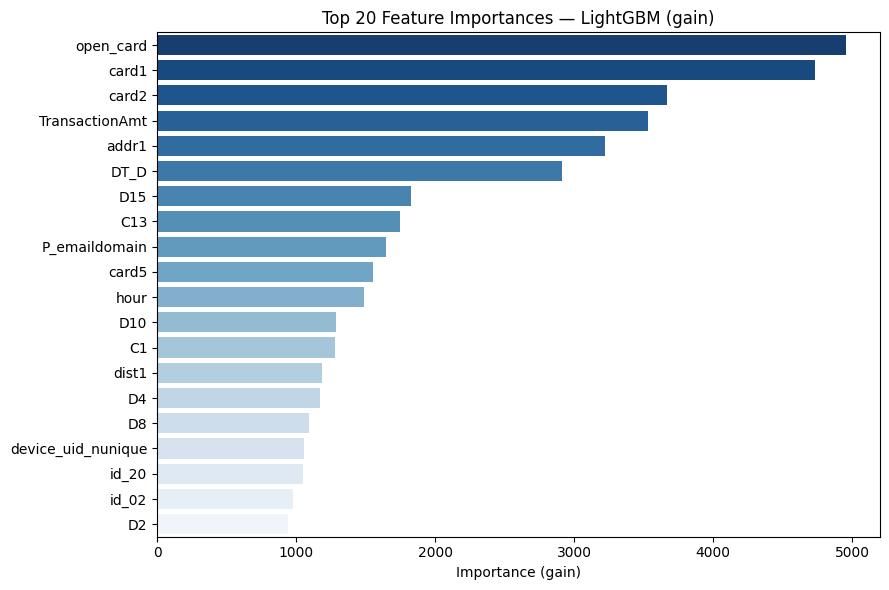

In [44]:
# Feature importance — addresses the "masked features" challenge in the business requirements
importances = lgb_model.feature_importances_
feat_names  = X_train.columns.tolist()

feat_df = (pd.DataFrame({'feature': feat_names, 'importance': importances})
           .sort_values('importance', ascending=False)
           .head(20))

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_df, x='importance', y='feature', palette='Blues_r')
plt.title('Top 20 Feature Importances — LightGBM (gain)')
plt.xlabel('Importance (gain)')
plt.ylabel('')
plt.tight_layout()
plt.show()


# **3. BUSINESS COST CONVERSION & THRESHOLD OPTIMIZATION**

In [51]:
# Threshold optimization runs on the held-out TEST set
amount_test = X_test['TransactionAmt'].values
# (amount_val kept for reference if needed)
amount_val = X_val['TransactionAmt'].values
mean_amount_train = X_train['TransactionAmt'].mean()


In [52]:

CHOSEN_ALPHA  = 0.02
Ca            = CHOSEN_ALPHA * mean_amount_train   

print(f"Mean TransactionAmt (train) : ${mean_amount_train:,.2f}")
print(f"Chosen alpha                : {CHOSEN_ALPHA:.0%}")
print(f"Ca (admin cost per review)  : ${Ca:,.2f}")

Mean TransactionAmt (train) : $134.60
Chosen alpha                : 2%
Ca (admin cost per review)  : $2.69


**FUNCTION 1: Cost function**

In [53]:
def compute_cost(y_true, y_pred_label, amount, Ca):
    """
    Bahnsen et al. 2013 cost function:
      TP (catch fraud)  → pay Ca to verify
      FN (miss fraud)   → lose full Amt
      FP (false alarm)  → pay Ca to verify
      TN (correct pass) → $0
    """
    y_true       = np.asarray(y_true)
    y_pred_label = np.asarray(y_pred_label)
    amount       = np.asarray(amount)
    cost = (y_true       * (y_pred_label * Ca + (1 - y_pred_label) * amount)
            + (1 - y_true) *  y_pred_label * Ca)
    return cost.sum()


**FUNCTION 2: Scan threshold 0.01 -> 0.95, find the optimized threshold that minimizes cost** 


In [54]:
def scan_thresholds(y_true, y_prob, amount, Ca):
    thresholds = np.concatenate([
        np.arange(0.01, 0.05, 0.001),  
        np.arange(0.01, 0.05)  
    ])
    records = []
    for t in thresholds:
        y_pred      = (y_prob >= t).astype(int)
        cost        = compute_cost(y_true, y_pred, amount, Ca)
        flagged_pct = y_pred.mean() * 100
        records.append((t, cost, flagged_pct))
    return pd.DataFrame(records, columns=['threshold', 'cost', 'flagged_pct'])

**FUNCTION 3: Caculate Projected Financial Savings compared to 0.5 default threshold**


In [55]:
def operational_report(y_true, y_prob, threshold, amount, Ca,
                       cost_default, baseline_no_model, label=''):
    y_pred      = (y_prob >= threshold).astype(int)
    n_flagged   = int(y_pred.sum())
    n_total     = len(y_pred)
    precision   = precision_score(y_true, y_pred, zero_division=0)
    recall      = recall_score   (y_true, y_pred, zero_division=0)
    f1          = f1_score       (y_true, y_pred, zero_division=0)
    cost        = compute_cost(y_true, y_pred, amount, Ca)
    savings_vs_baseline = (baseline_no_model - cost) / baseline_no_model * 100
    savings_vs_default  = (cost_default - cost)      / cost_default      * 100

    print(f"  {label}  (threshold = {threshold:.4f})")
    print(f"    Flagged           : {n_flagged:,} / {n_total:,}  ({n_flagged/n_total*100:.1f}%)")
    print(f"    Precision         : {precision:.3f}")
    print(f"    Recall            : {recall:.3f}")
    print(f"    F1                : {f1:.3f}")
    print(f"    Total Cost        : ${cost:,.2f}")
    print(f"    Saves vs baseline : {savings_vs_baseline:.1f}%  "
          f"| Saves vs default 0.5 : {savings_vs_default:.1f}%")
    print()
    return dict(threshold=threshold, n_flagged=n_flagged,
                precision=precision, recall=recall, f1=f1,
                cost=cost,
                savings_vs_baseline=savings_vs_baseline,
                savings_vs_default=savings_vs_default)

Scan threshold with Alpha = 2% (Ca) 

In [56]:
scan_df  = scan_thresholds(y_test, lgb_pred_test, amount_test, Ca)
best_row = scan_df.loc[scan_df['cost'].idxmin()]

opt_threshold     = best_row['threshold']
cost_optimal      = best_row['cost']
cost_default      = compute_cost(y_test,
                                 (lgb_pred_test >= 0.5).astype(int),
                                 amount_test, Ca)
baseline_no_model = amount_test[np.asarray(y_test) == 1].sum()


print(f"\nBaseline (no model)          : ${baseline_no_model:,.2f}")
print(f"Cost @ default threshold 0.5 : ${cost_default:,.2f}")
print(f"Cost @ optimal threshold     : ${cost_optimal:,.2f}  "
      f"(threshold = {opt_threshold:.4f})")

print(f"\nSavings (optimal vs default) : ${cost_default - cost_optimal:,.2f}")


Baseline (no model)          : $469,608.50
Cost @ default threshold 0.5 : $344,620.63
Cost @ optimal threshold     : $105,777.78  (threshold = 0.0170)

Savings (optimal vs default) : $238,842.85


Cost vs Threshold (fixed Ca)

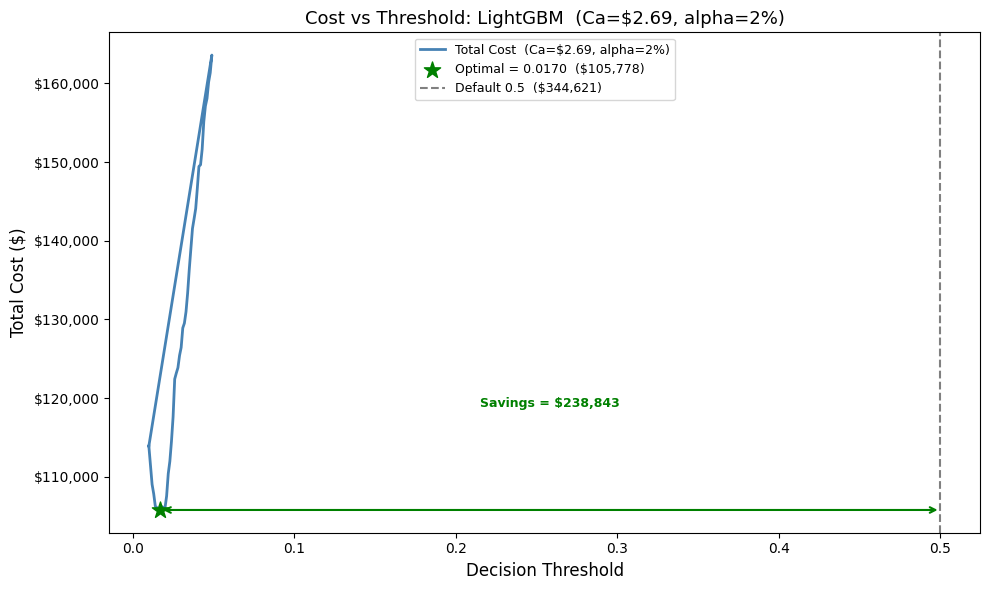

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))

# Đường cost
ax.plot(scan_df['threshold'], scan_df['cost'],
        color='steelblue', linewidth=2,
        label=f'Total Cost  (Ca=${Ca:.2f}, alpha={CHOSEN_ALPHA:.0%})')

# Điểm optimal
ax.scatter([opt_threshold], [cost_optimal],
           color='green', marker='*', s=150, zorder=5,
           label=f'Optimal = {opt_threshold:.4f}  (${cost_optimal:,.0f})')

# Đường dọc default 0.5
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.5,
           label=f'Default 0.5  (${cost_default:,.0f})')


ax.annotate('',
            xy=(0.5, cost_optimal),
            xytext=(opt_threshold, cost_optimal),
            arrowprops=dict(arrowstyle='<->', color='green', lw=1.5))

ax.text((opt_threshold + 0.5) / 2, cost_optimal * 1.12,
        f'Savings = ${cost_default - cost_optimal:,.0f}',
        ha='center', va='bottom',
        color='green', fontsize=9, fontweight='bold')

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Total Cost ($)', fontsize=12)
ax.set_title(f'Cost vs Threshold: LightGBM  '
             f'(Ca=${Ca:.2f}, alpha={CHOSEN_ALPHA:.0%})', fontsize=13)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

**Operational report at different threshold**

In [58]:

print("OPERATIONAL FEASIBILITY REPORT")


r_default = operational_report(
    y_test, lgb_pred_test, 0.5,
    amount_test, Ca, cost_default, baseline_no_model,
    label='Default threshold (0.5)')

r_optimal = operational_report(
    y_test, lgb_pred_test, opt_threshold,
    amount_test, Ca, cost_default, baseline_no_model,
    label=f'Cost-optimal threshold ({opt_threshold:.4f})')




OPERATIONAL FEASIBILITY REPORT
  Default threshold (0.5)  (threshold = 0.5000)
    Flagged           : 1,345 / 88,581  (1.5%)
    Precision         : 0.816
    Recall            : 0.356
    F1                : 0.495
    Total Cost        : $344,620.63
    Saves vs baseline : 26.6%  | Saves vs default 0.5 : 0.0%

  Cost-optimal threshold (0.0170)  (threshold = 0.0170)
    Flagged           : 19,699 / 88,581  (22.2%)
    Precision         : 0.134
    Recall            : 0.853
    F1                : 0.231
    Total Cost        : $105,777.78
    Saves vs baseline : 77.5%  | Saves vs default 0.5 : 69.3%



In [59]:
main_summary = pd.DataFrame([
  
    {'Scenario'      : 'Default threshold (0.5)',
     'Threshold'     : '0.5000',
     'Flagged %'     : f'{(lgb_pred_test >= 0.5).mean()*100:.1f}%',
     'Total Cost ($)': f'{cost_default:,.2f}',
     'Savings %'     : f'{(baseline_no_model-cost_default)/baseline_no_model*100:.1f}%'},
    {'Scenario'      : f'Cost-optimal ({opt_threshold:.4f})',
     'Threshold'     : f'{opt_threshold:.4f}',
     'Flagged %'     : f'{(lgb_pred_test >= opt_threshold).mean()*100:.1f}%',
     'Total Cost ($)': f'{cost_optimal:,.2f}',
     'Savings %'     : f'{(baseline_no_model-cost_optimal)/baseline_no_model*100:.1f}%'},

])

print(f"MAIN RESULTS  (Ca=${Ca:.2f}, alpha={CHOSEN_ALPHA:.0%})\n")
print(main_summary.to_string(index=False))


MAIN RESULTS  (Ca=$2.69, alpha=2%)

               Scenario Threshold Flagged % Total Cost ($) Savings %
Default threshold (0.5)    0.5000      1.5%     344,620.63     26.6%
  Cost-optimal (0.0170)    0.0170     22.2%     105,777.78     77.5%


**SENSITIVITY TABLE: fixed optimal threshold, varying Ca**: 

Across all Ca values, threshold= 0.0170 consistently outperforms default 0.5, recommendation is robust, even if Ca is estimated incorrectly.


In [60]:
print(f"Threshold fixed at {opt_threshold:.4f} (optimal under alpha={CHOSEN_ALPHA:.0%})\n")

sens_records = []
for alpha in [0.01, 0.02, 0.05]:
    Ca_i    = alpha * mean_amount_train
    cost_d  = compute_cost(y_test,
                           (lgb_pred_test >= 0.5).astype(int),
                           amount_test, Ca_i)
    cost_o  = compute_cost(y_test,
                           (lgb_pred_test >= opt_threshold).astype(int),
                           amount_test, Ca_i)
    savings = cost_d - cost_o
    sens_records.append({
        'alpha'          : f'{alpha:.0%}',
        'Ca ($)'         : f'{Ca_i:.2f}',
        'Cost @ 0.5 ($)' : f'{cost_d:,.2f}',
        'Cost @ opt ($)' : f'{cost_o:,.2f}',
        'Savings ($)'    : f'{savings:,.2f}',
        'Savings %'      : f'{savings/cost_d*100:.1f}%',
    })

print(pd.DataFrame(sens_records).to_string(index=False))


Threshold fixed at 0.0170 (optimal under alpha=2%)

alpha Ca ($) Cost @ 0.5 ($) Cost @ opt ($) Savings ($) Savings %
   1%   1.35     342,810.20      79,261.96  263,548.23     76.9%
   2%   2.69     344,620.63     105,777.78  238,842.85     69.3%
   5%   6.73     350,051.94     185,325.23  164,726.70     47.1%



Optimal threshold per Ca:

  alpha=1%  Ca=$1.35  →  optimal threshold = 0.0100

  alpha=2%  Ca=$2.69  →  optimal threshold = 0.0170

  alpha=5%  Ca=$6.73  →  optimal threshold = 0.0230

→ All optimal thresholds fall within the same low range, far from default 0.5, the recommendation does not  depend on knowing Ca precisely.

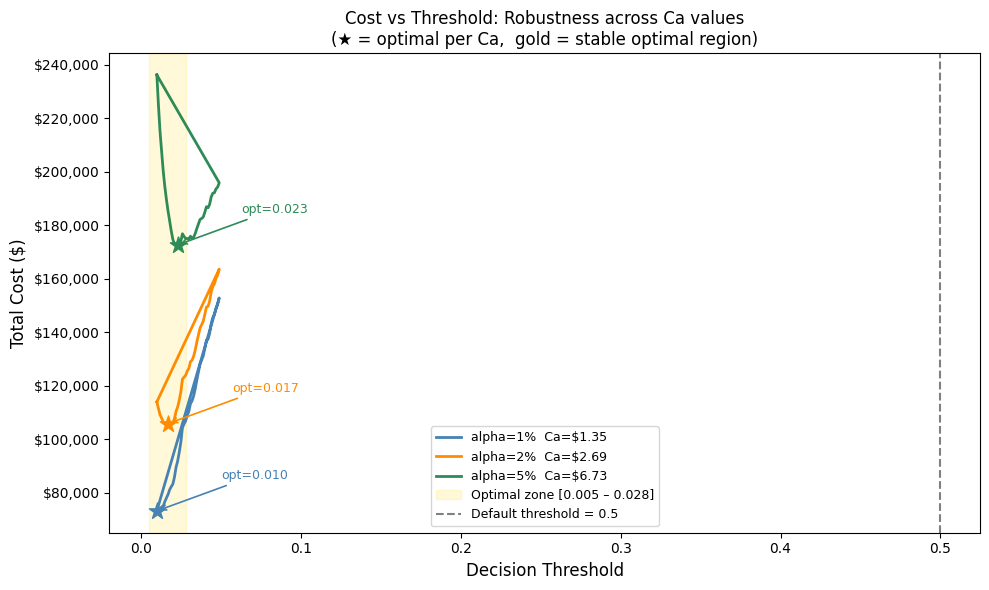

In [61]:
alpha_list = [0.01, 0.02, 0.05]
colors     = ['steelblue', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(10, 6))

opt_thresholds = {}

for alpha, color in zip(alpha_list, colors):
    Ca_i   = alpha * mean_amount_train
    scan_i = scan_thresholds(y_test, lgb_pred_test, amount_test, Ca_i)
    best_i = scan_i.loc[scan_i['cost'].idxmin()]
    opt_t  = best_i['threshold']
    opt_c  = best_i['cost']
    opt_thresholds[alpha] = opt_t

    ax.plot(scan_i['threshold'], scan_i['cost'],
            color=color, linewidth=2,
            label=f'alpha={alpha:.0%}  Ca=${Ca_i:.2f}')

    ax.scatter([opt_t], [opt_c],
               color=color, marker='*', s=150, zorder=5)

    ax.annotate(f'opt={opt_t:.3f}',
                xy=(opt_t, opt_c),
                xytext=(opt_t + 0.04, opt_c + 12000),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2),
                color=color, fontsize=9)

# Vùng highlight — tất cả optimal rơi vào đây
x_min = min(opt_thresholds.values()) - 0.005
x_max = max(opt_thresholds.values()) + 0.005
ax.axvspan(x_min, x_max, alpha=0.15, color='gold',
           label=f'Optimal zone [{x_min:.3f} – {x_max:.3f}]')

ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.5,
           label='Default threshold = 0.5')

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Total Cost ($)', fontsize=12)
ax.set_title('Cost vs Threshold: Robustness across Ca values\n'
             '(★ = optimal per Ca,  gold = stable optimal region)',
             fontsize=12)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


**BAYES MINIMUM RISK: Per-transaction threshold**


In [62]:

per_txn_threshold = Ca / amount_test        # shape = (n_test,)
bayes_pred        = (lgb_pred_test >= per_txn_threshold).astype(int)

# Metrics
cost_bayes      = compute_cost(y_test, bayes_pred, amount_test, Ca)
n_flagged_bayes = int(bayes_pred.sum())
flagged_pct_bayes = bayes_pred.mean() * 100
precision_bayes = precision_score(y_test, bayes_pred, zero_division=0)
recall_bayes    = recall_score(y_test,    bayes_pred, zero_division=0)
f1_bayes        = f1_score(y_test,        bayes_pred, zero_division=0)
savings_bayes_vs_baseline = (baseline_no_model - cost_bayes) / baseline_no_model * 100
savings_bayes_vs_default  = (cost_default - cost_bayes)      / cost_default      * 100


print(f"  Per-transaction threshold = Ca / Amt_i = ${Ca:.2f} / Amt_i")
print(f"\nFlagged      : {n_flagged_bayes:,} / {len(bayes_pred):,}  ({flagged_pct_bayes:.1f}%)")
print(f"Precision    : {precision_bayes:.3f}")
print(f"Recall       : {recall_bayes:.3f}")
print(f"F1           : {f1_bayes:.3f}")
print(f"Total Cost   : ${cost_bayes:,.2f}")
print(f"Saves vs baseline : {savings_bayes_vs_baseline:.1f}%  "
      f"|Saves vs default 0.5 : {savings_bayes_vs_default:.1f}%")
print()




  Per-transaction threshold = Ca / Amt_i = $2.69 / Amt_i

Flagged      : 16,298 / 88,581  (18.4%)
Precision    : 0.141
Recall       : 0.745
F1           : 0.237
Total Cost   : $86,266.90
Saves vs baseline : 81.6%  |Saves vs default 0.5 : 75.0%



**Comparision: Fixed threshold vs Bayes MR**

In [63]:

comparison_df = pd.DataFrame([
  
    {'Approach'       : 'Default threshold (0.5)',
     'Threshold'      : '0.5 (fixed)',
     'Flagged %'      : f'{(lgb_pred_test >= 0.5).mean()*100:.1f}%',
     'Total Cost ($)' : f'{cost_default:,.2f}',
     'Savings %'      : f'{(baseline_no_model-cost_default)/baseline_no_model*100:.1f}%'},
    {'Approach'       : f'Cost-optimal (fixed threshold)',
     'Threshold'      : f'{opt_threshold:.4f} (fixed)',
     'Flagged %'      : f'{(lgb_pred_test >= opt_threshold).mean()*100:.1f}%',
     'Total Cost ($)' : f'{cost_optimal:,.2f}',
     'Savings %'      : f'{(baseline_no_model-cost_optimal)/baseline_no_model*100:.1f}%'},
    {'Approach'       : 'Bayes Minimum Risk',
     'Threshold'      : 'Ca/Amt_i (per-transaction)',
     'Flagged %'      : f'{flagged_pct_bayes:.1f}%',
     'Total Cost ($)' : f'{cost_bayes:,.2f}',
     'Savings %'      : f'{savings_bayes_vs_baseline:.1f}%'},
])

print(comparison_df.to_string(index=False))




                      Approach                  Threshold Flagged % Total Cost ($) Savings %
       Default threshold (0.5)                0.5 (fixed)      1.5%     344,620.63     26.6%
Cost-optimal (fixed threshold)             0.0170 (fixed)     22.2%     105,777.78     77.5%
            Bayes Minimum Risk Ca/Amt_i (per-transaction)     18.4%      86,266.90     81.6%


**INTERPRETATION**:

  Fixed optimal threshold : 1 threshold for all transaction → easy to deploy
                            
  Bayes Minimum Risk      : different threshold = Ca/Amt_i for different transaction → theorically more optimal but complex to deploy, and most of the caculated threshold is within our fixed optimal threshold range 

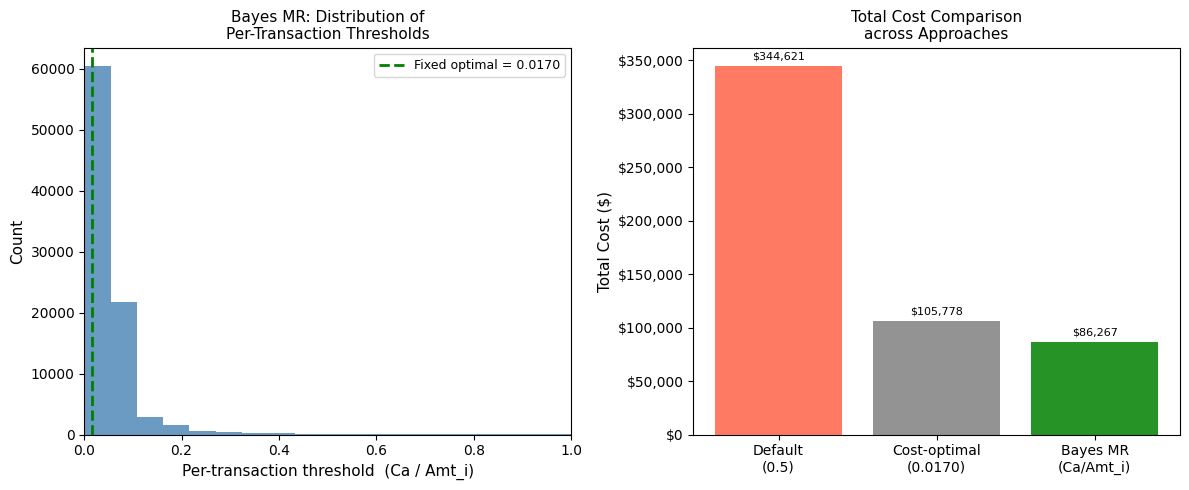

In [64]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LEFT: distribution của per-transaction threshold (Bayes MR)
axes[0].hist(per_txn_threshold, bins=100, color='steelblue',
             edgecolor='none', alpha=0.8)
axes[0].axvline(opt_threshold, color='green', linestyle='--',
                linewidth=2, label=f'Fixed optimal = {opt_threshold:.4f}')
axes[0].set_xlabel('Per-transaction threshold  (Ca / Amt_i)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Bayes MR: Distribution of\nPer-Transaction Thresholds', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)

# RIGHT: Compare Total Cost 3 scenarios
scenarios  = ['Default\n(0.5)', f'Cost-optimal\n({opt_threshold:.4f})', 'Bayes MR\n(Ca/Amt_i)']
costs      = [ cost_default, cost_optimal, cost_bayes]
bar_colors = ['tomato', 'gray', 'green', 'steelblue']

bars = axes[1].bar(scenarios, costs, color=bar_colors, edgecolor='none', alpha=0.85)
axes[1].set_ylabel('Total Cost ($)', fontsize=11)
axes[1].set_title('Total Cost Comparison\nacross Approaches', fontsize=11)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Label số trên mỗi bar
for bar, cost in zip(bars, costs):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + baseline_no_model * 0.01,
                 f'${cost:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()




**TECHNICAL EVALUATION: Fixed Optimal vs Bayes MR**

Even though Bayes MR helps to save more in terms of cost, that does not mean it is the best approach. We need to look at their evaluation metrics as well to determine which one is optimal
 

In [65]:

pred_default = (lgb_pred_test >= 0.5).astype(int)
pred_optimal = (lgb_pred_test >= opt_threshold).astype(int)
pred_bayes   = bayes_pred

approaches = {
    f'Default (0.5)'                    : pred_default,
    f'Cost-optimal ({opt_threshold:.4f})': pred_optimal,
    'Bayes MR (Ca/Amt_i)'               : pred_bayes,
}



In [66]:

print("TECHNICAL METRICS COMPARISON")

metric_records = []
for name, pred in approaches.items():
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    prec   = precision_score(y_test, pred, zero_division=0)
    rec    = recall_score(y_test,    pred, zero_division=0)
    f1     = f1_score(y_test,        pred, zero_division=0)
    fpr    = fp / (fp + tn)   # False Positive Rate
    flagged_pct = pred.mean() * 100

    metric_records.append({
        'Approach'    : name,
        'Flagged %'   : f'{flagged_pct:.1f}%',
        'Precision'   : f'{prec:.3f}',
        'Recall'      : f'{rec:.3f}',
        
    })

metrics_df = pd.DataFrame(metric_records)
print(metrics_df.to_string(index=False))




TECHNICAL METRICS COMPARISON
             Approach Flagged % Precision Recall
        Default (0.5)      1.5%     0.816  0.356
Cost-optimal (0.0170)     22.2%     0.134  0.853
  Bayes MR (Ca/Amt_i)     18.4%     0.141  0.745


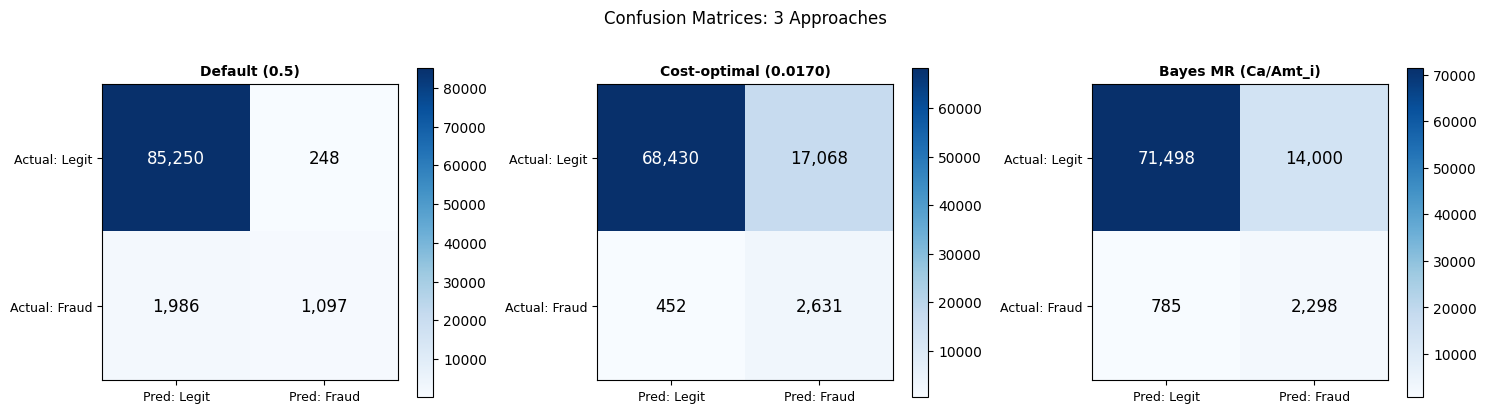

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, approaches.items()):
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap='Blues')

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}',
                    ha='center', va='center', fontsize=12,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: Legit', 'Pred: Fraud'], fontsize=9)
    ax.set_yticklabels(['Actual: Legit', 'Actual: Fraud'], fontsize=9)
    ax.set_title(name, fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax)

plt.suptitle('Confusion Matrices: 3 Approaches', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()




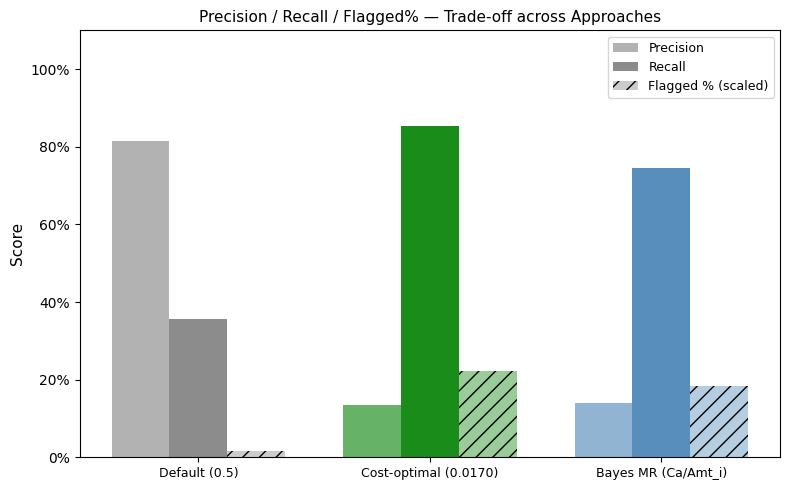

In [68]:

fig, ax = plt.subplots(figsize=(8, 5))

names      = list(approaches.keys())
precisions = [float(r['Precision']) for r in metric_records]
recalls    = [float(r['Recall'])    for r in metric_records]
flagged    = [float(r['Flagged %'].replace('%','')) for r in metric_records]
colors_bar = ['gray', 'green', 'steelblue']

x      = np.arange(len(names))
width  = 0.25

ax.bar(x - width, precisions, width, label='Precision', color=[c for c in colors_bar], alpha=0.6)
ax.bar(x,         recalls,    width, label='Recall',    color=[c for c in colors_bar], alpha=0.9)
ax.bar(x + width, [f/100 for f in flagged], width,
       label='Flagged % (scaled)', color=[c for c in colors_bar], alpha=0.4, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision / Recall / Flagged% — Trade-off across Approaches', fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()




# Sprint 6: Feature Live Risk Feed 

Analytics: Predictive Analytics 

Question: How risky is each transaction before we approve it? (Live Risk Feed Feature) 

In [90]:

risk_feed = pd.DataFrame({
    'TransactionID': df.loc[X_test.index, 'TransactionID'].values,
    'TransactionAmt': amount_test,          # already computed in the threshold-optimization section
    'risk_score': lgb_pred_test
}).sort_values('risk_score', ascending=False)

high_risk_pct = (lgb_pred_test >= opt_threshold).mean()   # opt_threshold comes from Q4's scan
top_transaction = risk_feed.iloc[0]

In [91]:
review_queue = risk_feed[risk_feed['risk_score'] >= opt_threshold].copy()
review_queue['suggested_action'] = np.where(
    review_queue['risk_score'] >= 0.9, 'Block',
    np.where(review_queue['risk_score'] >= 0.5, 'Manual Review', 'Monitor')
)
review_queue.to_csv('q1_review_queue.csv', index=False)

In [92]:
q1 = pd.read_csv('q1_review_queue.csv')
q1.head()

,TransactionID,TransactionAmt,risk_score,suggested_action
0,3534449,150.0,0.999886,Block
1,3556851,300.0,0.999777,Block
2,3513829,600.0,0.999612,Block
3,3545361,300.0,0.999611,Block
4,3556658,300.0,0.999589,Block


# Sprint 7: Fraud Catch Rate Monitor 

Analytics: Predictive Analytics 

Question:  How many of the frauds coming in are we acutally catching?

In [93]:
catch_rate_summary = {
    'model': 'LightGBM',
    'recall': r_optimal['recall'],
    'precision': r_optimal['precision'],
    'n_flagged': r_optimal['n_flagged'],
    'threshold_used': float(opt_threshold),
}


catch_rate_df = pd.DataFrame([{
    'Model'                  : catch_rate_summary['model'],
    'Fraud Caught'           : f"{catch_rate_summary['recall']*100:.1f}%",       
    'Alert Accuracy'         : f"{catch_rate_summary['precision']*100:.1f}%",    
    'Transactions Under Review': f"{catch_rate_summary['n_flagged']:,}",         
    'Sensitivity Level'      : f"{catch_rate_summary['threshold_used']:.4f}",    
}])

catch_rate_df

,Model,Fraud Caught,Alert Accuracy,Transactions Under Review,Sensitivity Level
0,LightGBM,85.3%,13.4%,"19,699",0.0170


# Sprint 8: Safe Operating Range 

Analytics: Prescriptive Analytics 

Question:  Given our team's size, what's the safe range for how aggressively we block transactions? 

In [94]:

capacities_to_test = [200, 300, 500, 700, 1000, 1500]
thresholds_to_test = [0.010, 0.017, 0.023, 0.030, 0.050]
daily_volume = df.groupby('DT_D').size().mean()    

rows = []
for cap in capacities_to_test:
    for t in thresholds_to_test:
        pred_at_t = (lgb_pred_test >= t).astype(int)
        expected_cases = daily_volume * pred_at_t.mean()
        used_pct = expected_cases / cap

        if used_pct > 1.0:
            status = 'Over'
            gap = expected_cases - cap
            suggestion = f"Lower sensitivity or add {round(gap)} more reviews/day capacity"
        else:
            status = 'Under'
            headroom = cap - expected_cases
            suggestion = f"Safe — {round(headroom)} reviews/day of spare capacity"

        rows.append({
            'team_capacity': cap,
            'blocking_sensitivity': t,
            'expected_daily_cases': round(expected_cases),
            'capacity_used_pct': round(used_pct, 3),
            'status': status,
            'suggestion': suggestion,
        })

capacity_grid = pd.DataFrame(rows)
capacity_grid.to_csv('q3_capacity_sensitivity_grid.csv', index=False)

capacity_grid

,team_capacity,blocking_sensitivity,expected_daily_cases,capacity_used_pct,status,suggestion
0,200,0.010,1110,5.550,Over,Lower sensitivity or add 910 more reviews/day ...
1,200,0.017,722,3.608,Over,Lower sensitivity or add 522 more reviews/day ...
2,200,0.023,551,2.753,Over,Lower sensitivity or add 351 more reviews/day ...
3,200,0.030,438,2.191,Over,Lower sensitivity or add 238 more reviews/day ...
4,200,0.050,289,1.445,Over,Lower sensitivity or add 89 more reviews/day c...
5,300,0.010,1110,3.700,Over,Lower sensitivity or add 810 more reviews/day ...
6,300,0.017,722,2.405,Over,Lower sensitivity or add 422 more reviews/day ...
7,300,0.023,551,1.835,Over,Lower sensitivity or add 251 more reviews/day ...
8,300,0.030,438,1.461,Over,Lower sensitivity or add 138 more reviews/day ...
9,300,0.050,289,0.963,Under,Safe — 11 reviews/day of spare capacity


# Sprint 9: Staffing Planner 

Analytics: Prescriptive Analytics 

Question: When should we schedule extra review staff to cover the riskiest hours?

In [97]:


TEAM_CAPACITY_PER_HOUR = 25   # replace with real number

hour_risk = pd.DataFrame({
    'hour': X_test['hour'].values,
    'risk_score': lgb_pred_test
})
test_days = (df.loc[X_test.index, 'DT_D'].max() - df.loc[X_test.index, 'DT_D'].min()) + 1

hourly_forecast = hour_risk.groupby('hour').agg(
    avg_predicted_risk=('risk_score', 'mean')
).reset_index()

flagged_per_hour_total = hour_risk.groupby('hour')['risk_score'] \
    .apply(lambda s: (s >= opt_threshold).sum())
hourly_forecast['expected_flagged_count'] = (flagged_per_hour_total / test_days).values

hourly_forecast['capacity_used_pct'] = hourly_forecast['expected_flagged_count'] / TEAM_CAPACITY_PER_HOUR
hourly_forecast['staffing_status'] = np.where(
    hourly_forecast['capacity_used_pct'] > 1.0, 'Add staff', 'Sufficient'
)

staffing_plan = hourly_forecast.sort_values('hour')

staffing_plan.to_csv('q_staffing_recommendation.csv', index=False)


staffing_plan

,hour,avg_predicted_risk,expected_flagged_count,capacity_used_pct,staffing_status
0,0,0.028185,36.000000,1.440000,Add staff
1,1,0.030459,29.516129,1.180645,Add staff
2,2,0.036833,25.741935,1.029677,Add staff
3,3,0.044940,22.580645,0.903226,Sufficient
4,4,0.061934,13.612903,0.544516,Sufficient
5,5,0.062083,9.000000,0.360000,Sufficient
6,6,0.068514,7.322581,0.292903,Sufficient
7,7,0.085657,5.322581,0.212903,Sufficient
8,8,0.041700,3.258065,0.130323,Sufficient
9,9,0.034891,4.096774,0.163871,Sufficient


Hour 7: rare but high-risk transactions. Hour 20: common, lower-risk but drives the most review workload.

# Sprint 10: Saving Impact 

Analytics: Prescriptive Analytics 

Question: How much does the new system save us compared to the traditional approach?

In [96]:

per_txn_threshold = Ca / amount_test
bayes_pred = (lgb_pred_test >= per_txn_threshold).astype(int)
cost_bayes = compute_cost(y_test, bayes_pred, amount_test, Ca)

settings_comparison = pd.DataFrame([
    {
        'Setting': 'Default (0.5)',
        'Sensitivity': '0.5 fixed',
        'Total Cost ($)': cost_default,
        'Savings vs Baseline': (baseline_no_model - cost_default) / baseline_no_model,
    },
    {
        'Setting': 'Cost-Optimal',
        'Sensitivity': f'{opt_threshold:.4f} fixed',
        'Total Cost ($)': cost_optimal,
        'Savings vs Baseline': (baseline_no_model - cost_optimal) / baseline_no_model,
    },
    {
        'Setting': 'Bayes Minimum Risk',
        'Sensitivity': 'Per-transaction ',
        'Total Cost ($)': cost_bayes,
        'Savings vs Baseline': (baseline_no_model - cost_bayes) / baseline_no_model,
    },
])

# Export raw numbers for dashboard
settings_comparison.to_json('q4_settings_comparison.json', orient='records', indent=2)

# Pretty table for notebook viewing
display_df = settings_comparison.copy()
display_df['Total Cost ($)'] = display_df['Total Cost ($)'].map('{:,.0f}'.format)
display_df['Savings vs Baseline'] = display_df['Savings vs Baseline'].map('{:.1%}'.format)
display_df

,Setting,Sensitivity,Total Cost ($),Savings vs Baseline
0,Default (0.5),0.5 fixed,"344,621",26.6%
1,Cost-Optimal,0.0170 fixed,"105,778",77.5%
2,Bayes Minimum Risk,Per-transaction,"86,267",81.6%



## Cost-Sensitive Threshold Optimization: Final Summary

| Approach | Threshold | Flagged % | Precision | Recall | Total Cost ($) | Savings vs Baseline* |
|---|---|---|---|---|---|---|
| Default (0.5) | 0.5 fixed | 1.5% | 0.816 | 0.356 | 344,621 | 26.6% |
| Cost-optimal | 0.017 fixed | 22.2% | 0.134 | 0.853 | 105,778 | 77.5% |
| Bayes MR | Ca/Amt_i | 18.4% | 0.141 | 0.745 | 86,267 | 81.6% |




 
 **Baseline (no model):** represents the scenario where no fraud detection system exists, every fraudulent transaction goes undetected and the full transaction amount is lost. 


## Key Observations

**1. Default threshold (0.5): conservative but costly**
With a Precision of 0.816, nearly every flagged transaction is genuine fraud. However, a Recall of only 0.356 means the model misses 64.4% of actual fraud cases entirely. While the low flag rate (1.5%) keeps operational workload minimal, it comes at a steep financial cost, the majority of fraud slips through undetected, leaving total losses at $344,621.

**2. Cost-optimal (0.017): best financial outcome under a fixed threshold, but operationally infeasible**
By lowering the threshold to 0.017, the model catches 85.3% of fraud (Recall = 0.853), reducing total cost to $105,778, a 77.5% saving over the no-model baseline. The trade-off is a Precision of only 0.134, meaning 87% of flagged transactions are false alarms, and 22.2% of all transactions (~19,699 cases) require review. No fraud operations team can sustainably handle that volume in practice.

**3. Bayes Minimum Risk (Ca/Amt_i): lowest cost and most financially aligned**
Bayes MR achieves the lowest total cost at $86,267 (81.6% savings) while flagging slightly fewer transactions than the cost-optimal approach (18.4% vs 22.2%). The key insight is how it allocates risk: instead of applying a single threshold to every transaction, it assigns a per-transaction threshold of Ca/Amt_i, meaning a $2,000 transaction only needs P(fraud) > 0.001 to be flagged, while a $10 transaction requires P(fraud) > 0.27. This directly mirrors real-world financial risk: investigation effort is automatically concentrated where the monetary exposure is highest, which is precisely the business objective stated in the requirements.

The only practical drawback is deployment complexity, rather than a single cutoff value, the system must compute Ca/Amt_i for each incoming transaction in real time. In a modern production environment this adds negligible computational overhead, but it must be clearly documented in the operational guidelines.



## Selected Approach: LightGBM with Cost-Optimal Threshold (0.017)

This project selects **LightGBM** as the final model combined with the **cost-optimal fixed threshold of 0.017** as the recommended production configuration, based on the following reasoning:

**Model selection: LightGBM:**
Among the three models evaluated (LightGBM, CatBoost, Neural Network), LightGBM achieved the highest AUC on the validation set (0.9355), outperforming CatBoost (0.9159) and Neural Network (0.8474). On tabular fraud data with mixed numeric and anonymized categorical features, gradient boosting consistently outperforms deep learning approaches, and LightGBM's efficiency makes it well-suited for high-volume transaction scoring.

**Threshold selection: Cost-optimal (0.017):**
The cost-optimal threshold is selected over Bayes MR for three reasons:

- **Higher Recall (0.853 vs 0.745):** In fraud detection, missing a fraudulent transaction results in a direct financial loss equal to the full transaction amount. A higher Recall means fewer fraud cases slip through undetected. This is the most critical metric for minimizing real-world financial damage.
- **Simpler deployment:** A single fixed threshold of 0.017 is straightforward to implement and audit in a production system. Every transaction above this probability is flagged, with no per-transaction computation required.
- **Substantial cost savings:** At $105,778 total cost, this approach saves 77.5% compared to the no-model baseline and reduces losses by $238,843 compared to the default threshold of 0.5, a concrete, reportable business KPI.

While the 22.2% flag rate represents a high operational workload, this is the direct consequence of prioritizing fraud suppression over investigator convenience, a trade-off that is financially sound given the asymmetric cost structure of the problem: verifying a legitimate transaction costs $2.69, while missing a fraudulent one costs the full transaction amount.


